# End-to-end data analytics project focused on forecasting retail demand and translating predictions into inventory planning decisions.

In [120]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import shap
import xgboost
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.base import clone



## 1. Business Understanding

Retail companies need to anticipate future demand to maintain adequate
inventory levels, reduce stockouts and avoid unnecessary overstock.

The objective of this project is to analyze historical sales and demand
patterns, identify the main factors influencing demand, build forecasting
models and translate their predictions into inventory planning decisions.

In [2]:
df_retail = pd.read_csv("sales_data.csv")
display(df_retail)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


### Explanation of the features

- Date: Date of the record.
- Store ID: Unique identifier for the store.
- Product ID: Unique identifier for the product.
- Category: Product category.
- Region: Geographical region of the store.
- Inventory Level: Units available in stock.
- Units Sold: Units sold on that day.
- Units Ordered: Units ordered for restocking.
- Price: Product price.
- Discount: Discount applied, if any.
- Weather Condition: Weather on the day of the record.
- Promotion: 1 if there was a promotion, 0 otherwise.
- Competitor Pricing: Price of a similar product from a competitor.
- Seasonality: Season (e.g., Winter, Spring).
- Epidemic: 1 if an epidemic occurred, 0 otherwise.
- Demand: Daily estimated demand for the product

## 2. Data Understanding

In [3]:
# feature types
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

In [4]:
# null values
df_retail.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [5]:
df_retail.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [6]:
print(f"Rows: {df_retail.shape[0]:,}")
print(f"Columns: {df_retail.shape[1]}")
print(f"Stores: {df_retail['Store ID'].nunique()}")
print(f"Products: {df_retail['Product ID'].nunique()}")
print(f"Categories: {df_retail['Category'].nunique()}")

Rows: 76,000
Columns: 16
Stores: 5
Products: 20
Categories: 5


In [7]:
# duplicates
df_retail.duplicated().sum()

np.int64(0)

In [8]:
# date check
date_check = pd.to_datetime(df_retail["Date"])

print(f"Start date: {date_check.min().date()}")
print(f"End date: {date_check.max().date()}")
print(f"Days covered: {(date_check.max() - date_check.min()).days}")

Start date: 2022-01-01
End date: 2024-01-30
Days covered: 759


In [9]:
# Check completeness of the store-product time series
records_per_series = (
    df_retail
    .groupby(["Store ID", "Product ID"])
    .size()
)

print(records_per_series.describe())

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64


In [10]:
# categories of the cualitative features

print(df_retail["Category"].value_counts())
print(df_retail["Region"].value_counts())
print(df_retail["Weather Condition"].value_counts())
print(df_retail["Seasonality"].value_counts())

Category
Groceries      30400
Furniture      13680
Clothing       12160
Toys           10640
Electronics     9120
Name: count, dtype: int64
Region
North    30400
South    15200
East     15200
West     15200
Name: count, dtype: int64
Weather Condition
Cloudy    24360
Sunny     22980
Rainy     17500
Snowy     11160
Name: count, dtype: int64
Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64


In [11]:
# daily logs
records_per_day = df_retail.groupby("Date").size()

print(records_per_day.describe())

# Every day contains one observation for each of the 100 store-product combinations.

count    760.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
dtype: float64


In [12]:
df_retail[["Store ID", "Region"]].drop_duplicates().sort_values("Store ID")

# Two of the stores belongs to the North Region, while other Regions only have one store

,Store ID,Region
0,S001,North
20,S002,South
40,S003,East
60,S004,West
80,S005,North


### Initial Data Overview

The dataset contains 76,000 daily observations covering the period from January 2022 to January 2024, across 5 stores and 20 products.

No missing values or duplicated rows were detected during the initial inspection. The dataset appears to follow a structured panel format, with daily observations for different store-product combinations.

The categorical variables show consistent labels, while numerical variables present different levels of dispersion, particularly inventory and restocking quantities.

The `Date` variable is currently stored as an object and will be converted to datetime during the data preparation stage. Binary variables such as `Promotion` and `Epidemic` will also be reviewed before modeling.

A deeper analysis of distributions, temporal patterns and potential outliers will be carried out during the exploratory analysis.

## 3. Data Cleaning & Preparation

The initial inspection showed that the dataset is already highly structured: no missing values or duplicated records were found, and each store-product combination contains a complete daily time series.

Therefore, the data preparation stage will focus mainly on correcting data types, validating numerical values and organizing the dataset for temporal analysis.

In [13]:
df_retail

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [14]:
# Convert date into datetime format
df_retail["Date"] = pd.to_datetime(df_retail["Date"])
df_retail["Date"].dtype

dtype('<M8[ns]')

In [15]:
# Negative values check
numeric_cols = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Demand"
]

for col in numeric_cols:
    print(f"{col}: {(df_retail[col] < 0).sum()} negative values")

Inventory Level: 0 negative values
Units Sold: 0 negative values
Units Ordered: 0 negative values
Price: 0 negative values
Discount: 0 negative values
Competitor Pricing: 0 negative values
Demand: 0 negative values


In [16]:
# Prices check 
print("Price <= 0:", (df_retail["Price"] <= 0).sum())
print("Competitor Pricing <= 0:", (df_retail["Competitor Pricing"] <= 0).sum())

Price <= 0: 0
Competitor Pricing <= 0: 0


In [17]:
# binary variables
print("Promotion:", df_retail["Promotion"].unique())
print("Epidemic:", df_retail["Epidemic"].unique())

Promotion: [0 1]
Epidemic: [0 1]


### Sorting the Time Series

The dataset was sorted by `Store ID`, `Product ID` and `Date` to ensure that each store-product time series is arranged chronologically.

This step is important for later feature engineering, since lag variables and rolling statistics must always use the correct previous observations within each individual time series.

In [18]:
df_retail = (
    df_retail
    .sort_values(["Store ID", "Product ID", "Date"])
    .reset_index(drop=True)
)

df_retail.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110
5,2022-01-06,S001,P0001,Electronics,North,190,98,308,84.03,0,Sunny,0,95.54,Winter,0,146
6,2022-01-07,S001,P0001,Electronics,North,92,92,0,66.07,10,Snowy,0,63.57,Winter,0,87
7,2022-01-08,S001,P0001,Electronics,North,308,96,248,68.56,10,Snowy,1,80.99,Winter,0,113
8,2022-01-09,S001,P0001,Electronics,North,212,57,0,62.76,10,Sunny,0,67.11,Winter,0,87
9,2022-01-10,S001,P0001,Electronics,North,403,88,0,68.99,5,Cloudy,0,81.14,Winter,0,99


In [19]:
df_retail.tail(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
75990,2024-01-21,S005,P0020,Toys,North,181,60,0,23.89,15,Cloudy,1,25.17,Winter,0,68
75991,2024-01-22,S005,P0020,Toys,North,121,121,133,27.78,15,Sunny,1,32.10,Winter,0,112
75992,2024-01-23,S005,P0020,Toys,North,133,103,80,29.56,5,Snowy,0,32.88,Winter,0,97
75993,2024-01-24,S005,P0020,Toys,North,110,74,128,26.86,20,Cloudy,1,30.17,Winter,0,121
75994,2024-01-25,S005,P0020,Toys,North,164,65,0,24.89,10,Sunny,0,29.30,Winter,0,63
75995,2024-01-26,S005,P0020,Toys,North,99,99,133,34.99,0,Cloudy,0,37.50,Winter,0,134
75996,2024-01-27,S005,P0020,Toys,North,133,28,0,22.55,10,Snowy,0,26.95,Winter,0,38
75997,2024-01-28,S005,P0020,Toys,North,105,83,122,30.87,15,Cloudy,1,28.08,Winter,0,130
75998,2024-01-29,S005,P0020,Toys,North,144,112,94,31.95,5,Cloudy,0,31.33,Winter,0,105
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73


## 4. Exploratory Data Analysis

The original dataset contains 100 different store-product time series, resulting from 5 stores and 20 products.

To keep the analysis focused and interpretable, the exploratory analysis will be performed on a single store while preserving all 20 product-level time series.

This approach allows us to study demand patterns in detail without repeating the same analysis across 100 separate series, while still maintaining a realistic multi-product forecasting problem.

In [20]:
# Selecting the store

store_summary = (
    df_retail
    .groupby("Store ID")["Demand"]
    .agg(["mean", "std", "sum"])
)

store_summary["cv"] = store_summary["std"] / store_summary["mean"]

store_summary

,mean,std,sum,cv
Store ID,,,,
S001,101.814013,47.131647,1547573,0.462919
S002,106.938882,45.608125,1625471,0.426488
S003,106.468684,47.424239,1618324,0.445429
S004,100.634934,45.991886,1529651,0.457017
S005,105.729276,48.269190,1607085,0.456536


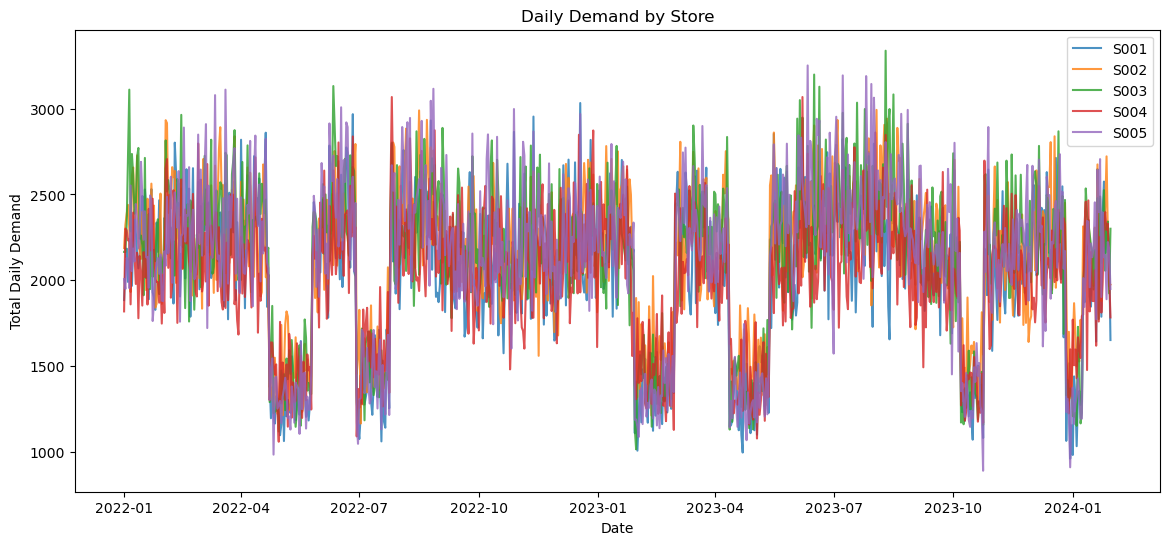

In [21]:
# Ploting daily demand by store
daily_store_demand = (
    df_retail
    .groupby(["Date", "Store ID"])["Demand"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for store in daily_store_demand["Store ID"].unique():
    store_data = daily_store_demand[
        daily_store_demand["Store ID"] == store
    ]
    
    plt.plot(
        store_data["Date"],
        store_data["Demand"],
        label=store,
        alpha=0.8
    )

plt.title("Daily Demand by Store")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()
plt.show()

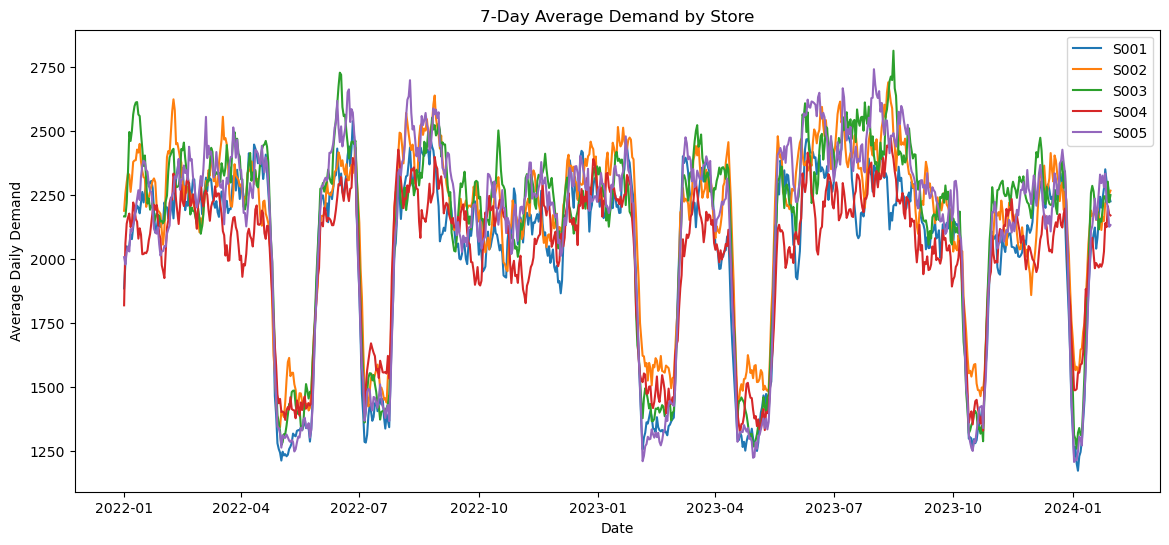

In [22]:
# 7-day rolling average by store
daily_store_demand["Demand_7d_avg"] = (
    daily_store_demand
    .groupby("Store ID")["Demand"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

plt.figure(figsize=(14, 6))

for store in daily_store_demand["Store ID"].unique():
    store_data = daily_store_demand[
        daily_store_demand["Store ID"] == store
    ]

    plt.plot(
        store_data["Date"],
        store_data["Demand_7d_avg"],
        label=store
    )

plt.title("7-Day Average Demand by Store")
plt.xlabel("Date")
plt.ylabel("Average Daily Demand")
plt.legend()
plt.show()

### Store Selection

The five stores show very similar demand patterns over time, with comparable levels and synchronized seasonal fluctuations.

To simplify the analysis while keeping a representative case, store `S003` was selected for the remainder of the project. This allows us to focus on 20 product-level time series without losing the general demand dynamics observed across the full dataset.

In [23]:
# New df creation

df_store = df_retail[df_retail["Store ID"] == "S003"].copy()

df_store.shape

(15200, 16)

In [24]:
df_store

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
30400,2022-01-01,S003,P0001,Toys,East,182,109,193,16.85,10,Sunny,0,15.48,Winter,0,112
30401,2022-01-02,S003,P0001,Toys,East,73,73,0,15.76,5,Cloudy,0,16.81,Winter,0,91
30402,2022-01-03,S003,P0001,Toys,East,193,117,316,18.83,10,Cloudy,1,20.46,Winter,0,168
30403,2022-01-04,S003,P0001,Toys,East,76,76,0,15.15,10,Sunny,0,16.99,Winter,0,95
30404,2022-01-05,S003,P0001,Toys,East,316,141,409,18.50,20,Sunny,1,18.46,Winter,0,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45595,2024-01-26,S003,P0020,Clothing,East,593,82,0,60.98,10,Snowy,0,73.09,Winter,0,69
45596,2024-01-27,S003,P0020,Clothing,East,511,127,0,78.96,5,Snowy,0,71.91,Winter,0,114
45597,2024-01-28,S003,P0020,Clothing,East,384,192,635,81.08,15,Cloudy,1,72.02,Winter,0,161
45598,2024-01-29,S003,P0020,Clothing,East,192,79,0,73.80,5,Snowy,0,83.84,Winter,0,109


### Product-Level Demand Overview

After selecting store `S003`, the next step is to compare the demand behavior of its 20 products.

This analysis will help identify differences in average demand and variability between products, and later select a few representative time series for a more detailed temporal analysis.

In [25]:
# Demand summary by product
product_summary = (
    df_store
    .groupby("Product ID")["Demand"]
    .agg(["mean", "std", "min", "max", "sum"])
)

product_summary["cv"] = (
    product_summary["std"] / product_summary["mean"]
)

product_summary = product_summary.sort_values(
    "mean",
    ascending=False
)

product_summary

,mean,std,min,max,sum,cv
Product ID,,,,,,
P0002,123.196053,49.006114,19,327,93629,0.397790
P0007,122.180263,46.409847,20,289,92857,0.379847
P0019,122.051316,48.347243,4,333,92759,0.396122
P0013,121.698684,48.807816,15,343,92491,0.401055
P0009,121.184211,47.609138,4,311,92100,0.392866
P0010,121.048684,47.542495,4,305,91997,0.392755
P0004,120.092105,47.628469,19,283,91270,0.396600
P0014,119.400000,45.699286,16,311,90744,0.382741
P0015,119.180263,50.480906,4,358,90577,0.423568


In [26]:
product_categories = (
    df_store[["Product ID", "Category"]]
    .drop_duplicates()
)

product_summary = (
    product_summary
    .reset_index()
    .merge(product_categories, on="Product ID", how="left")
    .set_index("Product ID")
)

product_summary

,mean,std,min,max,sum,cv,Category
Product ID,,,,,,,
P0002,123.196053,49.006114,19,327,93629,0.397790,Groceries
P0007,122.180263,46.409847,20,289,92857,0.379847,Groceries
P0019,122.051316,48.347243,4,333,92759,0.396122,Groceries
P0013,121.698684,48.807816,15,343,92491,0.401055,Groceries
P0009,121.184211,47.609138,4,311,92100,0.392866,Groceries
P0010,121.048684,47.542495,4,305,91997,0.392755,Groceries
P0004,120.092105,47.628469,19,283,91270,0.396600,Groceries
P0014,119.400000,45.699286,16,311,90744,0.382741,Groceries
P0015,119.180263,50.480906,4,358,90577,0.423568,Groceries


### Representative Product Selection

To avoid repeating the same time series analysis across all 20 products, three representative products were selected based on their demand level and variability:

- `P0002` (Groceries): high average demand with moderate variability.
- `P0008` (Clothing): medium demand and relatively stable behavior.
- `P0006` (Toys): lower average demand and the highest relative variability.

These products will be used for the detailed time series analysis, while the final forecasting model will still consider all 20 products.

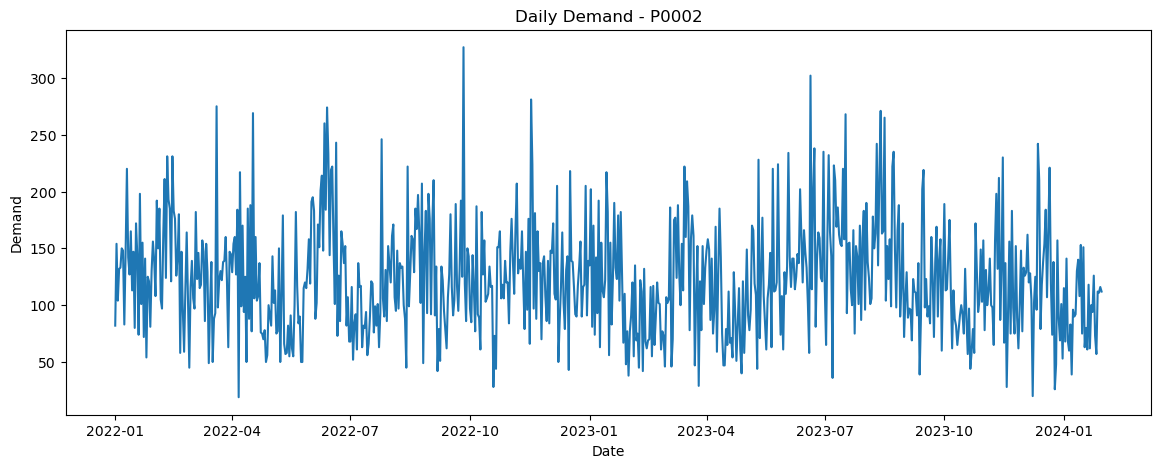

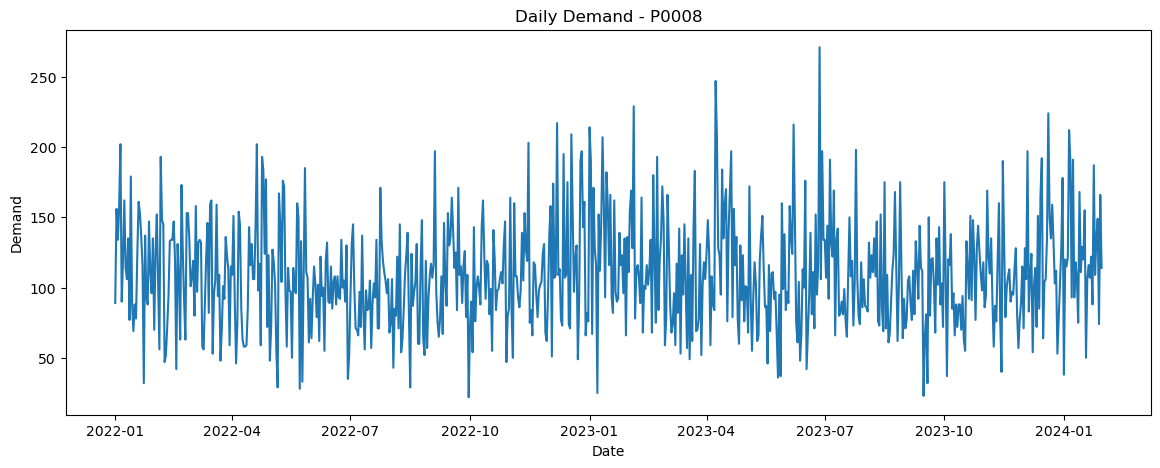

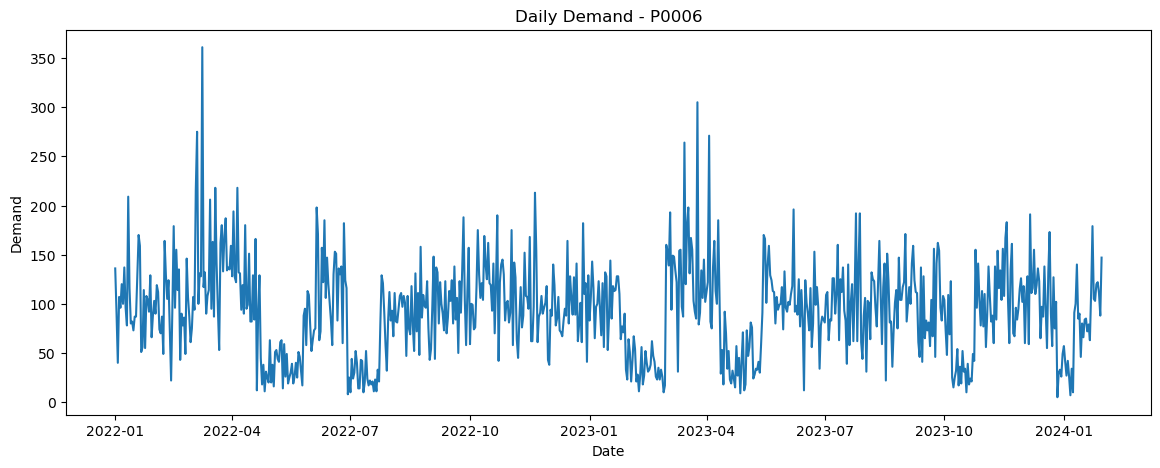

In [27]:
# Visual inspection

selected_products = ["P0002", "P0008", "P0006"]

for product in selected_products:
    product_data = df_store[
        df_store["Product ID"] == product
    ]

    plt.figure(figsize=(14, 5))
    plt.plot(product_data["Date"], product_data["Demand"])

    plt.title(f"Daily Demand - {product}")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.show()

### Initial Visual Inspection

The selected products show different demand behaviors.

`P0002` presents high demand with moderate variability and occasional peaks.  
`P0008` shows a more stable demand pattern with less pronounced fluctuations.  
`P0006` displays the highest variability, including strong demand peaks and several periods of clearly lower demand.

These differences confirm that the selected products provide useful representative cases for the detailed time series analysis.

### Outlier Detection

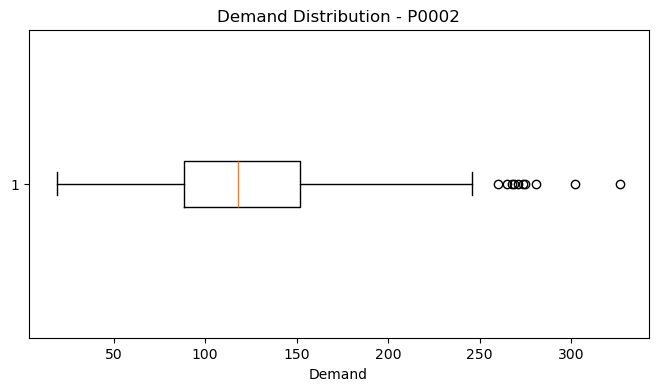

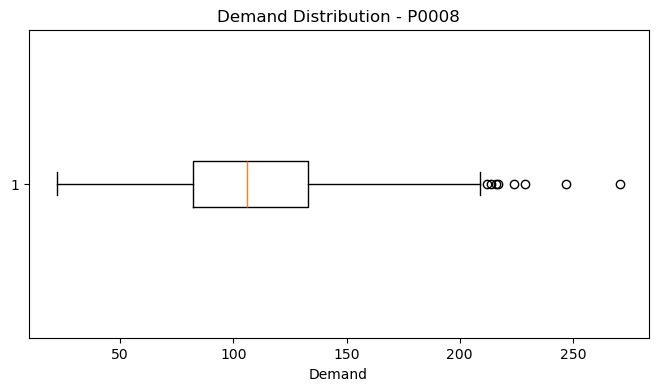

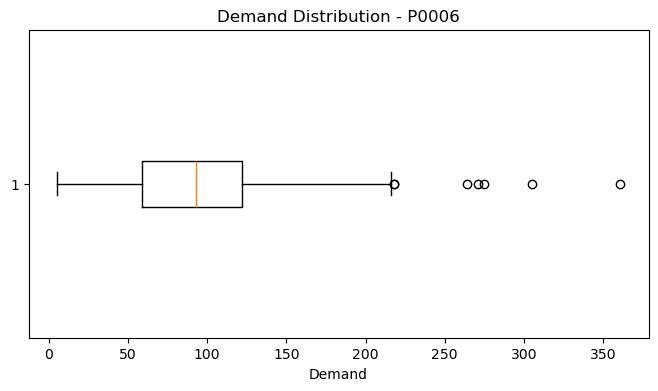

In [28]:
# Outlier detection using boxplots

selected_products = ["P0002", "P0008", "P0006"]

for product in selected_products:
    product_data = df_store[
        df_store["Product ID"] == product
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(product_data["Demand"], vert=False)

    plt.title(f"Demand Distribution - {product}")
    plt.xlabel("Demand")
    plt.show()

In [29]:
# Outlier detection using z-score method

df_selected = df_store[
    df_store["Product ID"].isin(selected_products)
].copy()

df_selected["Demand_Zscore"] = (
    df_selected
    .groupby("Product ID")["Demand"]
    .transform(zscore)
)

df_selected["Potential_Outlier"] = (
    df_selected["Demand_Zscore"].abs() > 3
)

In [30]:
df_selected.groupby("Product ID")["Potential_Outlier"].sum()

Product ID
P0002    6
P0006    5
P0008    3
Name: Potential_Outlier, dtype: int64

### Outlier Detection

Boxplots revealed several high-demand observations across the selected products. To identify the most extreme values, a product-level Z-score was calculated using a threshold of `|Z| > 3`.

The method detected:

- `P0002`: 6 potential outliers
- `P0006`: 5 potential outliers
- `P0008`: 3 potential outliers

These observations will not be removed automatically. Their context will first be analyzed to determine whether they represent data errors or genuine demand peaks driven by business or seasonal factors.

In [31]:
# Looking each case

outliers = df_selected[
    df_selected["Potential_Outlier"]
].copy()

outlier_cols = [
    "Date",
    "Product ID",
    "Demand",
    "Demand_Zscore",
    "Price",
    "Discount",
    "Promotion",
    "Weather Condition",
    "Seasonality",
    "Epidemic",
    "Units Sold",
    "Inventory Level",
    "Units Ordered"
]

outliers[outlier_cols].sort_values(
    ["Product ID", "Demand_Zscore"],
    ascending=[True, False]
)

,Date,Product ID,Demand,Demand_Zscore,Price,Discount,Promotion,Weather Condition,Seasonality,Epidemic,Units Sold,Inventory Level,Units Ordered
31428,2022-09-26,P0002,327,4.161484,83.27,20,1,Sunny,Autumn,0,301,301,1027
31695,2023-06-20,P0002,302,3.651008,74.36,25,1,Sunny,Summer,0,248,463,1039
31480,2022-11-17,P0002,281,3.222208,76.72,15,1,Sunny,Autumn,0,171,254,797
31238,2022-03-20,P0002,275,3.099693,80.18,10,1,Sunny,Spring,0,249,249,808
31323,2022-06-13,P0002,274,3.079274,70.29,25,1,Sunny,Summer,0,195,297,0
31749,2023-08-13,P0002,271,3.018017,70.74,20,1,Sunny,Summer,0,314,1050,0
34267,2022-03-09,P0006,361,5.660192,70.18,10,1,Sunny,Spring,0,170,170,305
34648,2023-03-25,P0006,305,4.476559,56.14,20,1,Sunny,Spring,0,122,122,336
34263,2022-03-05,P0006,275,3.842469,59.46,10,0,Cloudy,Spring,0,230,240,285
34657,2023-04-03,P0006,271,3.757924,55.65,15,1,Sunny,Spring,0,137,137,288


In [32]:
df_selected["Demand_Sales_Gap"] = (
    df_selected["Demand"] - df_selected["Units Sold"]
)

df_selected["Fulfillment_Rate"] = (
    df_selected["Units Sold"] / df_selected["Demand"]
)


df_selected.loc[
    df_selected["Potential_Outlier"],
    [
        "Date",
        "Product ID",
        "Demand",
        "Units Sold",
        "Inventory Level",
        "Demand_Sales_Gap",
        "Fulfillment_Rate",
        "Promotion",
        "Discount"
    ]
].sort_values("Fulfillment_Rate")

,Date,Product ID,Demand,Units Sold,Inventory Level,Demand_Sales_Gap,Fulfillment_Rate,Promotion,Discount
34648,2023-03-25,P0006,305,122,122,183,0.400000,1,20
34638,2023-03-15,P0006,264,109,109,155,0.412879,1,20
34267,2022-03-09,P0006,361,170,170,191,0.470914,1,10
34657,2023-04-03,P0006,271,137,137,134,0.505535,1,15
31480,2022-11-17,P0002,281,171,254,110,0.608541,1,15
36119,2023-02-04,P0008,229,152,152,77,0.663755,1,15
36262,2023-06-27,P0008,271,187,187,84,0.690037,1,15
31323,2022-06-13,P0002,274,195,297,79,0.711679,1,25
31695,2023-06-20,P0002,302,248,463,54,0.821192,1,25
34263,2022-03-05,P0006,275,230,240,45,0.836364,0,10


### Outlier Assessment

The observations identified through the Z-score represent statistically unusual demand peaks, but no clear evidence suggests that they are data errors.

Most of these observations coincide with promotional periods and discounts, suggesting that the high demand values may reflect genuine commercial events. In several cases, units sold also match the reported inventory level, which could indicate potential stock constraints.

Since `Demand` represents estimated demand rather than observed sales, differences between `Demand` and `Units Sold` are not considered sufficient evidence to classify an observation as erroneous.

Therefore, the detected outliers were retained for the subsequent analysis.

### Sampling Frequency

Before performing time series analysis, the sampling frequency of the selected products was checked.

A consistent temporal frequency is important because techniques such as autocorrelation analysis, seasonal decomposition and lag-based feature engineering assume observations are ordered at regular time intervals.

In [33]:
for product in selected_products:
    product_dates = (
        df_store[df_store["Product ID"] == product]["Date"]
        .sort_values()
    )

    print(f"\n{product}")
    print(product_dates.diff().value_counts().head())


P0002
Date
1 days    759
Name: count, dtype: int64

P0008
Date
1 days    759
Name: count, dtype: int64

P0006
Date
1 days    759
Name: count, dtype: int64


In [34]:
for product in selected_products:
    product_dates = (
        df_store[df_store["Product ID"] == product]["Date"]
        .sort_values()
    )

    frequency = pd.infer_freq(product_dates)

    print(f"{product}: {frequency}")

P0002: D
P0008: D
P0006: D


### Time Series Analysis

### Autocorrelation Analysis

Autocorrelation was analyzed to determine whether current demand is related to its previous values and to identify potential recurring temporal patterns.

Detecting significant correlations at specific lags can reveal seasonality and help define relevant lag features for the forecasting models.

<Figure size 1200x400 with 0 Axes>

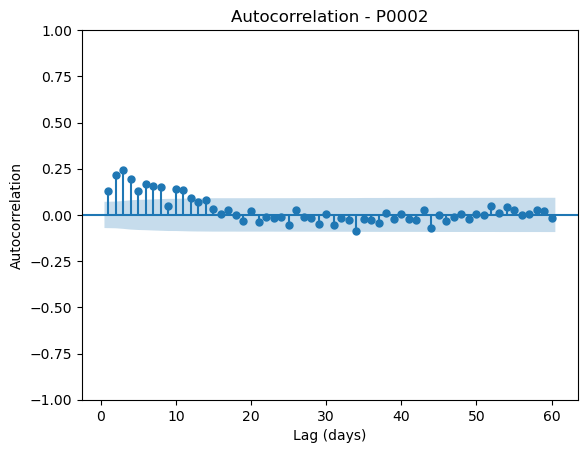

<Figure size 1200x400 with 0 Axes>

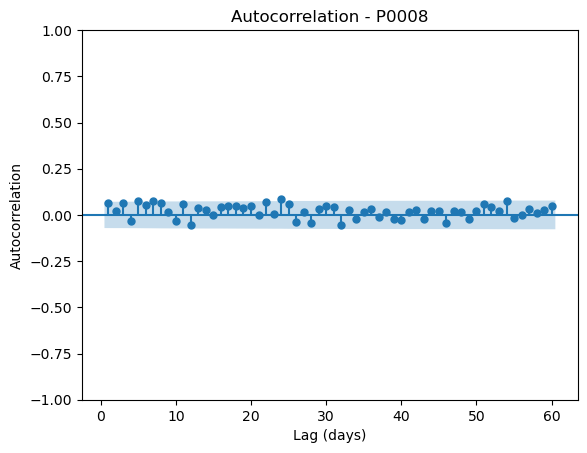

<Figure size 1200x400 with 0 Axes>

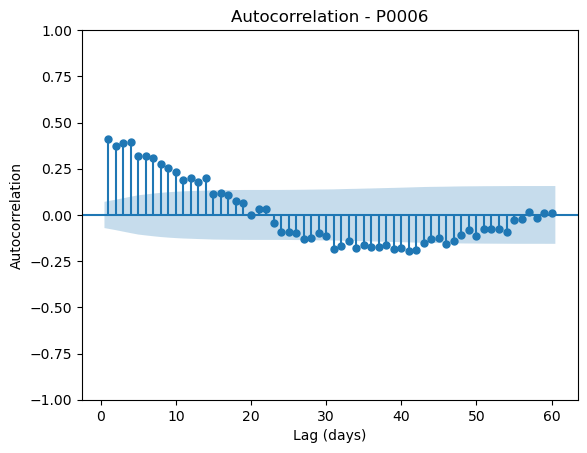

In [35]:
for product in selected_products:
    product_data = (
        df_store[df_store["Product ID"] == product]
        .sort_values("Date")
    )

    plt.figure(figsize=(12, 4))
    
    plot_acf(
        product_data["Demand"],
        lags=60,
        zero=False
    )

    plt.title(f"Autocorrelation - {product}")
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.show()

### Short-Term Autocorrelation

The 60-day autocorrelation analysis does not reveal a clear weekly seasonal pattern across the selected products.

`P0002` shows moderate short-term persistence, while `P0008` presents very weak autocorrelation. `P0006` exhibits a much stronger and slower-decaying temporal structure, suggesting that longer-term patterns may be present.

Therefore, a broader lag window will be explored before defining any seasonal period for the decomposition stage.

<Figure size 1200x400 with 0 Axes>

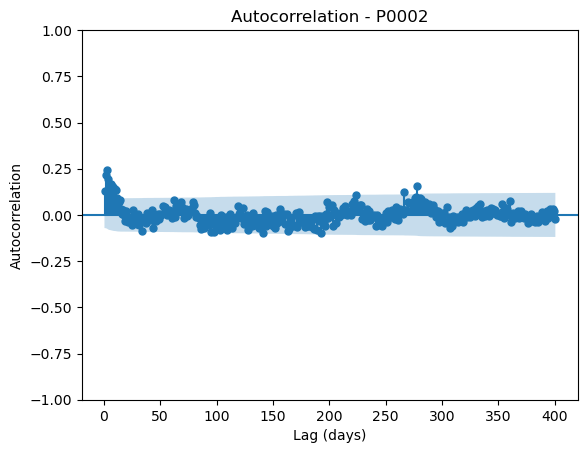

<Figure size 1200x400 with 0 Axes>

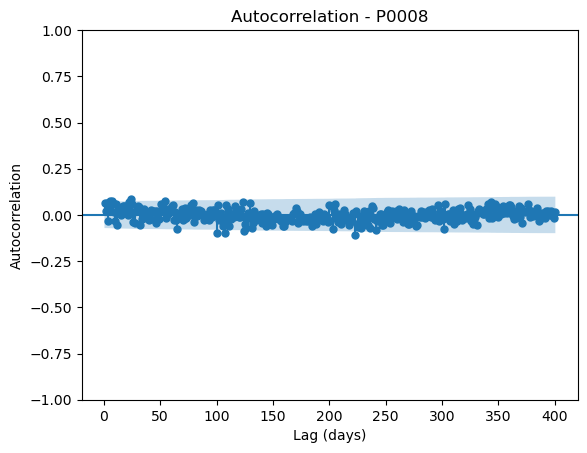

<Figure size 1200x400 with 0 Axes>

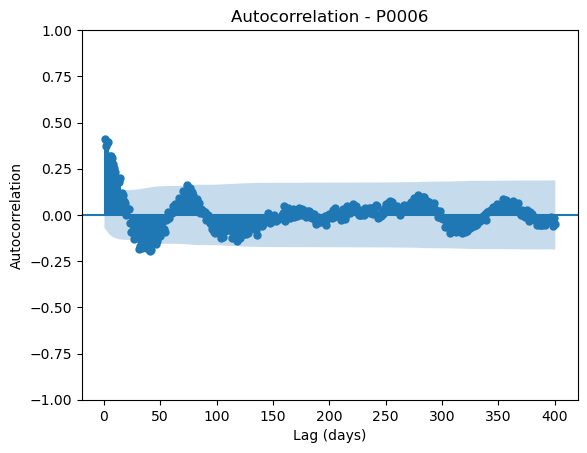

In [36]:
for product in selected_products:
    product_data = (
        df_store[df_store["Product ID"] == product]
        .sort_values("Date")
    )

    plt.figure(figsize=(12, 4))
    
    plot_acf(
        product_data["Demand"],
        lags=400,
        zero=False
    )

    plt.title(f"Autocorrelation - {product}")
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.show()

`P0006` shows a clear cyclical autocorrelation structure, with alternating positive and negative correlations over longer lags. The pattern suggests a possible cycle of approximately 80–90 days rather than a weekly or monthly seasonality.

A frequency-domain analysis will be performed to verify whether this periodicity represents a dominant seasonal component before selecting a period for seasonal decomposition.

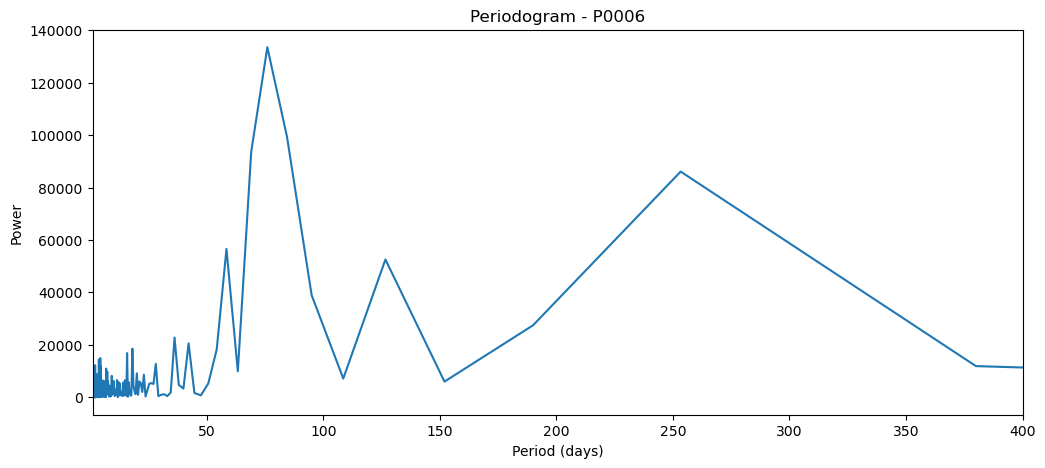

In [37]:
product_data = (
    df_store[df_store["Product ID"] == "P0006"]
    .sort_values("Date")
)

frequencies, power = periodogram(product_data["Demand"])

periods = 1 / frequencies[1:]
power = power[1:]

plt.figure(figsize=(12, 5))
plt.plot(periods, power)

plt.xlim(1, 400)
plt.title("Periodogram - P0006")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.show()

In [38]:
# Find the dominant period within a reasonable range
mask = (periods >= 2) & (periods <= 180)

dominant_period = periods[mask][np.argmax(power[mask])]

print(f"Dominant period: {dominant_period:.2f} days")

Dominant period: 76.00 days


### Stationarity Assessment

The visual inspection and autocorrelation analysis of `P0002` and `P0008` do not suggest a clear seasonal component or a persistent long-term trend.

Before applying any transformation such as differencing, the stationarity of both series will be evaluated using the Augmented Dickey-Fuller (ADF) and KPSS tests.

These tests will help determine whether the original series can be modeled directly or whether further transformations are required.

In [39]:
for product in ["P0002", "P0008"]:
    series = (
        df_store[df_store["Product ID"] == product]
        .sort_values("Date")["Demand"]
    )

    adf_result = adfuller(series)
    kpss_result = kpss(series, regression="c", nlags="auto")

    print(f"\n{product}")
    print(f"ADF p-value: {adf_result[1]:.4f}")
    print(f"KPSS p-value: {kpss_result[1]:.4f}")


P0002
ADF p-value: 0.0000
KPSS p-value: 0.1000

P0008
ADF p-value: 0.0000
KPSS p-value: 0.1000


C:\Users\Acer\AppData\Local\Temp\ipykernel_10332\757626174.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
C:\Users\Acer\AppData\Local\Temp\ipykernel_10332\757626174.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


### Stationarity Results

Both `P0002` and `P0008` show evidence of stationarity in their original form.

The ADF test rejects the presence of a unit root (`p < 0.05`), while the KPSS test does not reject the null hypothesis of stationarity (`p > 0.05`).

Therefore, no differencing transformation is required for these two series.

### Seasonal Decomposition

Unlike the other selected products, `P0006` shows a clear cyclical structure in its autocorrelation function.

The periodogram identified a dominant periodicity of approximately `76 days`, which will be used to decompose the series into trend, seasonal and residual components.

This decomposition will help assess whether the detected cycle represents a stable seasonal pattern and provide a cleaner residual component for further diagnostic analysis.

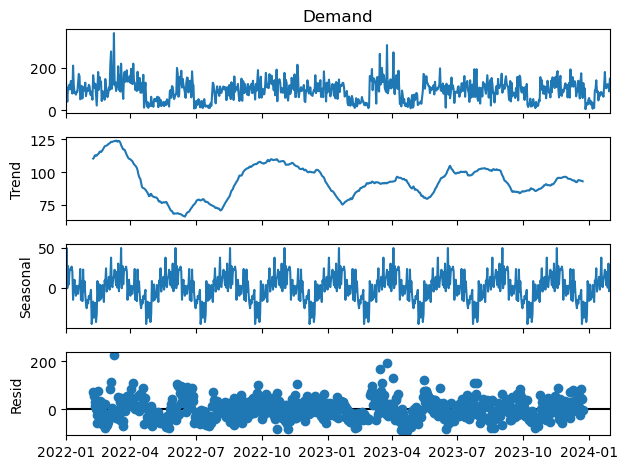

In [40]:
p0006 = (
    df_store[df_store["Product ID"] == "P0006"]
    .sort_values("Date")
    .set_index("Date")["Demand"]
)

decomposition = seasonal_decompose(
    p0006,
    model="additive",
    period=76
)

decomposition.plot()
plt.show()

### Residual Diagnostics - P0006

After decomposing `P0006` using the dominant 76-day periodicity, the residual component is analyzed to determine whether relevant temporal structure remains unexplained.

The residuals will be evaluated in terms of:

- Mean and overall distribution.
- Stationarity using the ADF and KPSS tests.
- Remaining temporal dependence through the autocorrelation function.
- Conditional heteroskedasticity using the Engle ARCH test.

Ideally, the residuals should fluctuate around zero, remain stationary and show little or no significant autocorrelation. Any remaining structure would suggest that the decomposition has not fully captured the temporal dynamics of the series.

In [41]:
p0006_resid = decomposition.resid.dropna()

print(f"Residual observations: {len(p0006_resid)}")
print(f"Residual mean: {p0006_resid.mean():.4f}")
print(f"Residual std: {p0006_resid.std():.4f}")

Residual observations: 684
Residual mean: 0.8974
Residual std: 41.9011


In [42]:
adf_resid = adfuller(p0006_resid)
kpss_resid = kpss(
    p0006_resid,
    regression="c",
    nlags="auto"
)

print(f"ADF p-value: {adf_resid[1]:.4f}")
print(f"KPSS p-value: {kpss_resid[1]:.4f}")

ADF p-value: 0.0000
KPSS p-value: 0.1000


C:\Users\Acer\AppData\Local\Temp\ipykernel_10332\3453260566.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resid = kpss(


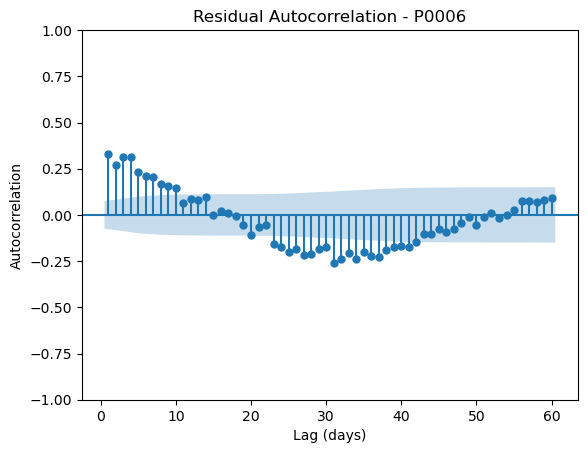

In [43]:
plot_acf(
    p0006_resid,
    lags=60,
    zero=False
)

plt.title("Residual Autocorrelation - P0006")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.show()

In [44]:
arch_stat, arch_pvalue, _, _ = het_arch(
    p0006_resid,
    nlags=10
)

print(f"Engle ARCH p-value: {arch_pvalue:.4f}")

Engle ARCH p-value: 0.0076


### Residual Diagnostic Results

The residual component of `P0006` is approximately centered around zero and shows evidence of stationarity according to both the ADF and KPSS tests.

However, the residual autocorrelation function reveals that significant temporal dependence remains, particularly at short and medium-term lags. This indicates that the 76-day seasonal decomposition captures part of the temporal structure but does not fully explain the dynamics of the series.

In addition, the Engle ARCH test (`p < 0.05`) suggests the presence of conditional heteroskedasticity, meaning that the residual variance is not constant over time.

Therefore, the remaining temporal structure and changing variability should be considered during the feature engineering and modeling stages.

### Demand Drivers and Contextual Variables

After analyzing the temporal behavior of demand, the next step is to explore how selected commercial and contextual variables are associated with demand levels.

The analysis will focus on `Promotion`, `Discount`, `Price`, `Seasonality` and `Category`, as these variables may help explain differences in demand and can potentially be used as predictors in the forecasting stage.

Categorical variables will be compared using aggregated demand statistics, while continuous variables will be explored through scatter plots and correlation analysis.

The objective of this section is to identify relevant associations rather than establish causal relationships.

In [45]:
# Promotion vs demand

promotion_summary = (
    df_store
    .groupby("Promotion")["Demand"]
    .agg(["mean", "median", "std", "count"])
)

promotion_summary

,mean,median,std,count
Promotion,,,,
0,97.16451,94.5,40.962525,10200
1,125.44920,122.0,53.644822,5000


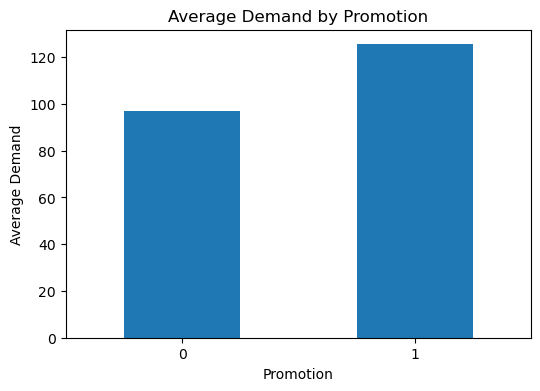

In [46]:
promotion_summary["mean"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Average Demand by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)
plt.show()

In [47]:
# Discount vs Demand

discount_summary = (
    df_store
    .groupby("Discount")["Demand"]
    .agg(["mean", "median", "count"])
)

discount_summary

,mean,median,count
Discount,,,
0,97.235242,95.0,3388
5,96.844581,94.0,3423
10,104.268099,100.0,4655
15,125.377152,121.0,1278
20,125.870942,122.0,1232
25,128.038399,124.0,1224


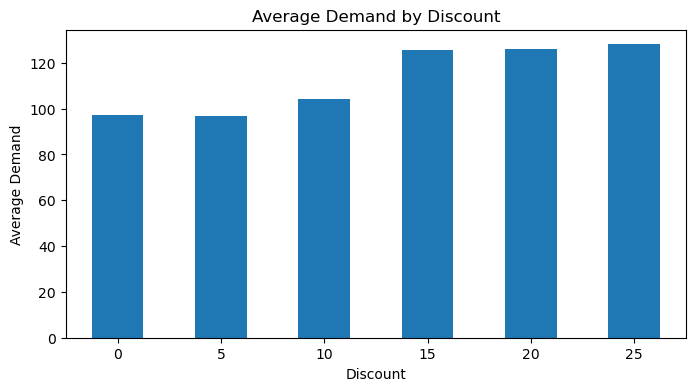

In [48]:
discount_summary["mean"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Average Demand by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)
plt.show()

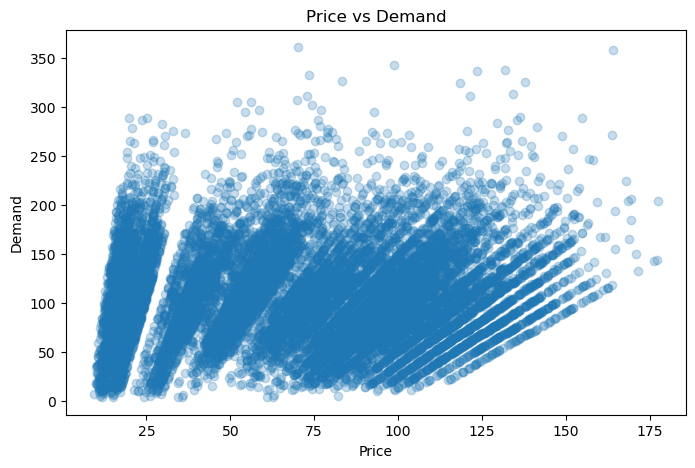

In [48]:
# Price Vs Demand

plt.figure(figsize=(8, 5))

plt.scatter(
    df_store["Price"],
    df_store["Demand"],
    alpha=0.25
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

In [49]:
price_corr = df_store["Price"].corr(df_store["Demand"])

print(f"Correlation between Price and Demand: {price_corr:.3f}")

Correlation between Price and Demand: 0.089


In [50]:
# Seasonality Vs Demand

seasonality_summary = (
    df_store
    .groupby("Seasonality")["Demand"]
    .agg(["mean", "median", "std"])
)

seasonality_summary

,mean,median,std
Seasonality,,,
Autumn,106.353297,103.0,42.526851
Spring,100.168478,97.0,46.950031
Summer,115.388315,109.0,52.635474
Winter,104.273571,101.0,45.885142


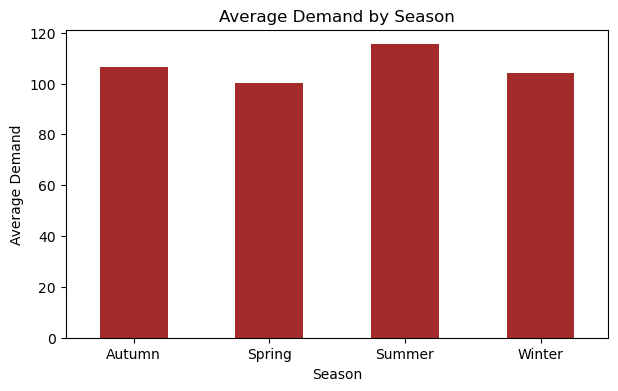

In [51]:
seasonality_summary["mean"].plot(
    kind="bar",
    figsize=(7, 4), color="brown"
)

plt.title("Average Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Demand")
plt.xticks(rotation=0)
plt.show()

In [52]:
# Category Vs Demand

category_summary = (
    df_store
    .groupby("Category")["Demand"]
    .agg(["mean", "median", "std", "sum"])
    .sort_values("mean", ascending=False)
)

category_summary

,mean,median,std,sum
Category,,,,
Groceries,121.114620,116.0,47.955385,828424
Clothing,109.455263,105.0,39.291126,166372
Electronics,107.982456,105.0,45.164908,246200
Toys,92.079825,92.0,45.705755,209942
Furniture,73.414912,73.0,31.433902,167386


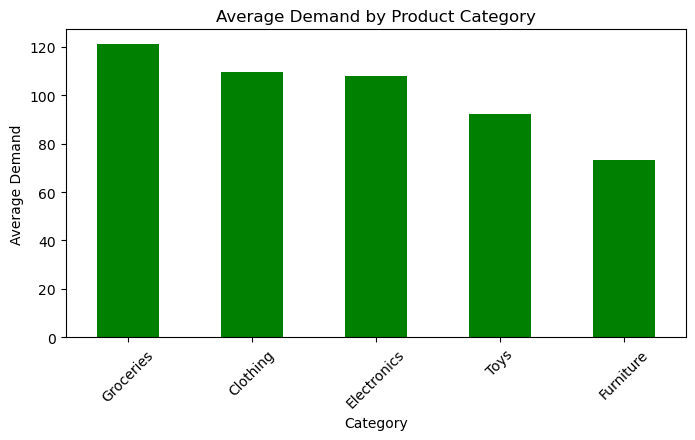

In [53]:
category_summary["mean"].plot(
    kind="bar",
    figsize=(8, 4), color="green"
)

plt.title("Average Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)
plt.show()

### Demand Driver Insights

The exploratory analysis reveals several relevant associations between contextual variables and product demand:

- **Promotions:** average demand is clearly higher during promotional periods, suggesting that promotions may be an important predictor for future demand.
- **Discounts:** demand remains relatively stable at low discount levels, but increases noticeably from discounts of approximately 15% and above. This suggests a possible nonlinear relationship between discount intensity and demand.
- **Price:** the global scatter plot does not show a simple linear relationship between price and demand. The visible clustered patterns suggest that price effects may differ between products, meaning that product-level interactions should be considered during modeling.
- **Seasonality:** demand varies across seasons, with the highest average demand observed during Summer and the lowest during Spring.
- **Product Category:** clear differences exist between categories. Groceries show the highest average demand, while Furniture presents the lowest, indicating that product characteristics are strongly associated with baseline demand levels.

Overall, the results suggest that `Promotion`, `Discount`, `Seasonality`, `Category` and product-specific price effects may provide useful explanatory information for the forecasting model.

### EDA Key Findings

The exploratory analysis provided several insights that will guide the forecasting stage:

- Demand patterns are broadly similar across stores, which justified focusing the analysis on a representative store (`S003`).
- Product-level demand differs substantially in both average level and variability, confirming the need to account for product-specific behavior.
- `P0006` shows a clear cyclical structure with a dominant periodicity of approximately 76 days, while `P0002` and `P0008` behave as stationary non-seasonal series.
- Statistically extreme demand values were retained, as they were generally associated with plausible commercial conditions such as promotions and discounts rather than obvious data errors.
- Promotions, discount levels, seasonality and product category show meaningful associations with demand and are therefore relevant candidates for feature engineering.

These findings will be used to define temporal and contextual features for the forecasting models.

## 5. Forecasting Approach

The forecasting objective is to predict future daily `Demand` for the 20 products of store `S003`.

The model will combine two types of information:

- **Historical demand features**, such as lags and rolling statistics, to capture recent behavior and recurring temporal patterns.
- **Contextual variables**, such as product, category, price, discount, promotion and seasonality, which may influence demand under different conditions.

Variables such as `Units Sold`, `Units Ordered` and `Inventory Level` will not be used initially as predictors to reduce the risk of data leakage.

A time-based train-test split will be used to preserve the chronological order of the data and evaluate the model on future observations.

## 6. Feature Engineering

### 6.1 Calendar Features

The `Date` variable contains temporal information that may help explain recurring demand patterns.

Since calendar information is known in advance, these variables can be safely used for forecasting without introducing data leakage.

The following features will be extracted:

- `DayOfWeek`: day of the week, from Monday (0) to Sunday (6).
- `Month`: month of the year.
- `WeekOfYear`: week number within the year.
- `IsWeekend`: binary indicator identifying Saturdays and Sundays.

These variables will later be encoded appropriately before modeling.

In [54]:
df_features = df_store.copy()

In [55]:
df_features["DayOfWeek"] = df_features["Date"].dt.dayofweek

df_features["Month"] = df_features["Date"].dt.month

df_features["WeekOfYear"] = (
    df_features["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df_features["IsWeekend"] = (
    df_features["DayOfWeek"]
    .isin([5, 6])
    .astype(int)
)

In [56]:
df_features[
    ["Date", "DayOfWeek", "Month", "WeekOfYear", "IsWeekend"]
].head(10)

,Date,DayOfWeek,Month,WeekOfYear,IsWeekend
30400,2022-01-01,5,1,52,1
30401,2022-01-02,6,1,52,1
30402,2022-01-03,0,1,1,0
30403,2022-01-04,1,1,1,0
30404,2022-01-05,2,1,1,0
30405,2022-01-06,3,1,1,0
30406,2022-01-07,4,1,1,0
30407,2022-01-08,5,1,1,1
30408,2022-01-09,6,1,1,1
30409,2022-01-10,0,1,2,0


### 6.2 Lag Features

Historical demand is one of the main sources of information for forecasting future demand.

Lag features represent previous demand values for each individual product and allow the model to capture short- and medium-term temporal dependencies.

The following lags will be created:

- `Lag 1` and `Lag 2`: recent demand behavior.
- `Lag 7` and `Lag 14`: short-term recurring patterns.
- `Lag 30`: medium-term demand information.
- `Lag 76`: the dominant periodicity identified during the time series analysis of `P0006`.

All lag features are calculated independently for each `Product ID` to prevent information from different product time series from being mixed.

In [57]:
lags = [1, 2, 7, 14, 30, 76]

for lag in lags:
    df_features[f"Demand_lag_{lag}"] = (
        df_features
        .groupby("Product ID")["Demand"]
        .shift(lag)
    )

In [58]:
df_features.loc[
    df_features["Product ID"] == "P0002",
    [
        "Date",
        "Product ID",
        "Demand",
        "Demand_lag_1",
        "Demand_lag_2",
        "Demand_lag_7",
        "Demand_lag_30",
        "Demand_lag_76"
    ]
].head(80)

,Date,Product ID,Demand,Demand_lag_1,Demand_lag_2,Demand_lag_7,Demand_lag_30,Demand_lag_76
31160,2022-01-01,P0002,82,NaN,NaN,NaN,NaN,NaN
31161,2022-01-02,P0002,154,82.0,NaN,NaN,NaN,NaN
31162,2022-01-03,P0002,104,154.0,82.0,NaN,NaN,NaN
31163,2022-01-04,P0002,132,104.0,154.0,NaN,NaN,NaN
31164,2022-01-05,P0002,133,132.0,104.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
31235,2022-03-17,P0002,50,138.0,100.0,147.0,183.0,NaN
31236,2022-03-18,P0002,88,50.0,138.0,86.0,176.0,82.0
31237,2022-03-19,P0002,93,88.0,50.0,154.0,126.0,154.0
31238,2022-03-20,P0002,275,93.0,88.0,129.0,143.0,104.0


In [59]:
df_features.loc[
    df_features["Product ID"] == "P0002",
    [
        "Date",
        "Product ID",
        "Demand",
        "Demand_lag_1",
        "Demand_lag_2",
        "Demand_lag_7",
        "Demand_lag_30",
        "Demand_lag_76"
    ]
].tail(80)

,Date,Product ID,Demand,Demand_lag_1,Demand_lag_2,Demand_lag_7,Demand_lag_30,Demand_lag_76
31840,2023-11-12,P0002,212,132.0,198.0,141.0,91.0,90.0
31841,2023-11-13,P0002,87,212.0,132.0,100.0,100.0,116.0
31842,2023-11-14,P0002,131,87.0,212.0,98.0,92.0,172.0
31843,2023-11-15,P0002,230,131.0,87.0,65.0,75.0,72.0
31844,2023-11-16,P0002,67,230.0,131.0,156.0,132.0,104.0
...,...,...,...,...,...,...,...,...
31915,2024-01-26,P0002,57,73.0,126.0,61.0,157.0,132.0
31916,2024-01-27,P0002,112,57.0,73.0,118.0,88.0,212.0
31917,2024-01-28,P0002,111,112.0,57.0,62.0,69.0,87.0
31918,2024-01-29,P0002,116,111.0,112.0,100.0,101.0,131.0


### 6.3 Rolling Statistics

Rolling statistics summarize the recent behavior of each product's demand and provide the model with information about short- and medium-term demand levels.

The following features will be created:

- `Rolling Mean 7`: average demand over the previous 7 days.
- `Rolling Mean 14`: average demand over the previous 14 days.
- `Rolling Mean 30`: average demand over the previous 30 days.
- `Rolling Std 7`: short-term demand variability.

All rolling statistics are calculated independently for each `Product ID` and shifted by one day to ensure that the current demand value is never used to predict itself.

In [60]:
for window in [7, 14, 30]:
    df_features[f"Demand_rolling_mean_{window}"] = (
        df_features
        .groupby("Product ID")["Demand"]
        .transform(
            lambda x: x.shift(1).rolling(window=window).mean()
        )
    )

# Rolling standard deviation
df_features["Demand_rolling_std_7"] = (
    df_features
    .groupby("Product ID")["Demand"]
    .transform(
        lambda x: x.shift(1).rolling(window=7).std()
    )
)

In [61]:
df_features.loc[
    df_features["Product ID"] == "P0002",
    [
        "Date",
        "Demand",
        "Demand_lag_1",
        "Demand_rolling_mean_7",
        "Demand_rolling_mean_14",
        "Demand_rolling_mean_30",
        "Demand_rolling_std_7"
    ]
].head(35)

,Date,Demand,Demand_lag_1,Demand_rolling_mean_7,Demand_rolling_mean_14,Demand_rolling_mean_30,Demand_rolling_std_7
31160,2022-01-01,82,NaN,NaN,NaN,NaN,NaN
31161,2022-01-02,154,82.0,NaN,NaN,NaN,NaN
31162,2022-01-03,104,154.0,NaN,NaN,NaN,NaN
31163,2022-01-04,132,104.0,NaN,NaN,NaN,NaN
31164,2022-01-05,133,132.0,NaN,NaN,NaN,NaN
31165,2022-01-06,150,133.0,NaN,NaN,NaN,NaN
31166,2022-01-07,148,150.0,NaN,NaN,NaN,NaN
31167,2022-01-08,83,148.0,129.000000,NaN,NaN,26.727015
31168,2022-01-09,147,83.0,129.142857,NaN,NaN,26.435006
31169,2022-01-10,220,147.0,128.142857,NaN,NaN,25.452103


### 6.4 Contextual Features

In addition to historical demand patterns, the forecasting model can benefit from contextual information that may influence future demand.

Based on the exploratory analysis, the initial model will include:

- `Product ID` and `Category`, to capture differences between products and product groups.
- `Price`, `Discount` and `Promotion`, representing commercial conditions that may affect demand.
- `Seasonality`, capturing broad seasonal differences.
- Calendar features previously extracted from `Date`.

Variables such as `Units Sold`, `Units Ordered` and `Inventory Level` are excluded from the initial forecasting model to reduce the risk of data leakage.

`Store ID` and `Region` are also excluded because the analysis is focused exclusively on store `S003`, making these variables constant and therefore uninformative for the model.

Other contextual variables such as weather, competitor pricing and epidemic conditions may be evaluated later if additional predictive information is required.

In [62]:
contextual_features = [
    "Product ID",
    "Category",
    "Price",
    "Discount",
    "Promotion",
    "Seasonality",
    "DayOfWeek",
    "Month",
    "WeekOfYear",
    "IsWeekend"
]

df_features[contextual_features].head()

,Product ID,Category,Price,Discount,Promotion,Seasonality,DayOfWeek,Month,WeekOfYear,IsWeekend
30400,P0001,Toys,16.85,10,0,Winter,5,1,52,1
30401,P0001,Toys,15.76,5,0,Winter,6,1,52,1
30402,P0001,Toys,18.83,10,1,Winter,0,1,1,0
30403,P0001,Toys,15.15,10,0,Winter,1,1,1,0
30404,P0001,Toys,18.50,20,1,Winter,2,1,1,0


### 6.5 Categorical Encoding

Machine learning models require numerical input, so categorical variables must be transformed before modeling.

One-Hot Encoding will be applied to:

- `Product ID`
- `Category`
- `Seasonality`
- `DayOfWeek`
- `Month`

This transformation creates binary variables representing each category without imposing an artificial numerical order.

`WeekOfYear` will initially remain numerical, while `IsWeekend`, `Promotion` and other binary variables are already represented as 0/1.

In [63]:
# Creating modeling dataset
df_model = df_features.copy()

categorical_cols = [
    "Product ID",
    "Category",
    "Seasonality",
    "DayOfWeek",
    "Month"
]

df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    dtype=int
)

In [64]:
df_model.head()

,Date,Store ID,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
30400,2022-01-01,S003,East,182,109,193,16.85,10,Sunny,0,...,0,0,0,0,0,0,0,0,0,0
30401,2022-01-02,S003,East,73,73,0,15.76,5,Cloudy,0,...,0,0,0,0,0,0,0,0,0,0
30402,2022-01-03,S003,East,193,117,316,18.83,10,Cloudy,1,...,0,0,0,0,0,0,0,0,0,0
30403,2022-01-04,S003,East,76,76,0,15.15,10,Sunny,0,...,0,0,0,0,0,0,0,0,0,0
30404,2022-01-05,S003,East,316,141,409,18.50,20,Sunny,1,...,0,0,0,0,0,0,0,0,0,0


In [65]:
print(f"Columns before encoding: {df_features.shape[1]}")
print(f"Columns after encoding: {df_model.shape[1]}")

Columns before encoding: 30
Columns after encoding: 73


### 6.6 Final Feature Set

After creating temporal, historical and contextual features, the final modeling dataset is defined.

Only variables that are available at the forecasting time and considered relevant to the initial model are retained.

The final feature set combines:

- Calendar information.
- Historical demand lags.
- Rolling demand statistics.
- Commercial variables such as price, discount and promotion.
- Encoded product, category and seasonal information.

`Date` will be preserved exclusively for the chronological train-test split, while `Demand` will be used as the prediction target.

Rows without sufficient historical information due to lag and rolling feature creation will be removed before modeling.

In [66]:
# Numerical and binary features
base_features = [
    "Price",
    "Discount",
    "Promotion",
    "WeekOfYear",
    "IsWeekend"
]

# Lag features
lag_features = [
    f"Demand_lag_{lag}"
    for lag in [1, 2, 7, 14, 30, 76]
]

# Rolling features
rolling_features = [
    "Demand_rolling_mean_7",
    "Demand_rolling_mean_14",
    "Demand_rolling_mean_30",
    "Demand_rolling_std_7"
]

# One-hot encoded features
encoded_features = [
    col for col in df_model.columns
    if col.startswith((
        "Product ID_",
        "Category_",
        "Seasonality_",
        "DayOfWeek_",
        "Month_"
    ))
]

feature_cols = (
    base_features
    + lag_features
    + rolling_features
    + encoded_features
)

In [67]:
print(f"Number of model features: {len(feature_cols)}")
print(feature_cols)

Number of model features: 63
['Price', 'Discount', 'Promotion', 'WeekOfYear', 'IsWeekend', 'Demand_lag_1', 'Demand_lag_2', 'Demand_lag_7', 'Demand_lag_14', 'Demand_lag_30', 'Demand_lag_76', 'Demand_rolling_mean_7', 'Demand_rolling_mean_14', 'Demand_rolling_mean_30', 'Demand_rolling_std_7', 'Product ID_P0001', 'Product ID_P0002', 'Product ID_P0003', 'Product ID_P0004', 'Product ID_P0005', 'Product ID_P0006', 'Product ID_P0007', 'Product ID_P0008', 'Product ID_P0009', 'Product ID_P0010', 'Product ID_P0011', 'Product ID_P0012', 'Product ID_P0013', 'Product ID_P0014', 'Product ID_P0015', 'Product ID_P0016', 'Product ID_P0017', 'Product ID_P0018', 'Product ID_P0019', 'Product ID_P0020', 'Category_Clothing', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Seasonality_Autumn', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter', 'DayOfWeek_0', 'DayOfWeek_1', 'DayOfWeek_2', 'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'Month_1',

In [68]:
model_data = df_model[
    ["Date", "Demand"] + feature_cols
].copy()

In [69]:
print(f"Rows before removing NaNs: {len(model_data):,}")

model_data = model_data.dropna().reset_index(drop=True)

print(f"Rows after removing NaNs: {len(model_data):,}")

Rows before removing NaNs: 15,200
Rows after removing NaNs: 13,680


In [70]:
print("Missing values:", model_data.isna().sum().sum())
print("Start date:", model_data["Date"].min())
print("End date:", model_data["Date"].max())
print("Rows:", model_data.shape[0])
print("Features:", len(feature_cols))

Missing values: 0
Start date: 2022-03-18 00:00:00
End date: 2024-01-30 00:00:00
Rows: 13680
Features: 63


In [71]:
product_dummy_cols = [
    col for col in feature_cols
    if col.startswith("Product ID_")
]

print(f"Product dummy variables: {len(product_dummy_cols)}")

Product dummy variables: 20


### Feature Engineering Summary

The final modeling dataset contains 63 predictive features combining calendar information, historical demand lags, rolling statistics, commercial variables and encoded categorical information.

The first 76 observations of each product were removed because they do not contain sufficient historical information for the longest lag feature.

The resulting dataset contains 13,680 observations across the 20 products of store `S003` and is now ready for the forecasting stage.

## 7. Forecasting Models

The final stage of the project focuses on forecasting daily product demand using supervised regression models.

Since this is a time series forecasting problem, model evaluation must preserve the chronological structure of the data. The models will therefore be trained using historical observations and evaluated on a future period that has not been used during training.

The forecasting strategy is designed as a **one-day-ahead prediction problem**, where demand for day `t` is predicted using information available up to day `t-1` together with contextual variables known for day `t`.

### 7.1 Temporal Train-Test Split

A random train-test split would introduce future information into the training process and would therefore provide an unrealistic evaluation.

Instead, the dataset will be divided chronologically. The first 80% of the available dates will be used for training and the remaining 20% for testing.

The same cutoff date is applied to all 20 products, ensuring that every product is trained on historical observations and evaluated over the same future period.

In [72]:
# Geting unique dates in chronological order
unique_dates = sorted(model_data["Date"].unique())

split_idx = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_idx]
test_dates = unique_dates[split_idx:]

train_data = model_data[
    model_data["Date"].isin(train_dates)
].copy()

test_data = model_data[
    model_data["Date"].isin(test_dates)
].copy()

In [73]:
print("Train period:")
print(train_data["Date"].min(), "→", train_data["Date"].max())
print(f"Rows: {len(train_data):,}")

print("\nTest period:")
print(test_data["Date"].min(), "→", test_data["Date"].max())
print(f"Rows: {len(test_data):,}")

Train period:
2022-03-18 00:00:00 → 2023-09-15 00:00:00
Rows: 10,940

Test period:
2023-09-16 00:00:00 → 2024-01-30 00:00:00
Rows: 2,740


In [74]:
print(
    "Products per train date:",
    train_data.groupby("Date").size().unique()
)

print(
    "Products per test date:",
    test_data.groupby("Date").size().unique()
)

Products per train date: [20]
Products per test date: [20]


### 7.2 Baseline Model

Before training machine learning models, a simple forecasting baseline is established to provide a reference for model performance.

Since the forecasting task is defined as one-day-ahead prediction, the baseline assumes that tomorrow's demand will be equal to the demand observed on the previous day.

In other words:

**Predicted Demand(t) = Demand(t-1)**

Any forecasting model developed afterwards should outperform this naive strategy to demonstrate that it is learning useful additional patterns from the available features.

In [75]:
# X and Y definition
X_train = train_data[feature_cols]
y_train = train_data["Demand"]

X_test = test_data[feature_cols]
y_test = test_data["Demand"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10940, 63)
X_test: (2740, 63)
y_train: (10940,)
y_test: (2740,)


In [76]:
# Baseline Naive

y_pred_baseline = test_data["Demand_lag_1"]

In [77]:
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mape = mean_absolute_percentage_error(y_test, y_pred_baseline) * 100

print(f"Baseline MAE:  {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline MAE:  39.80
Baseline RMSE: 51.64
Baseline MAPE: 51.97%


In [78]:
# r2

baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline R²: {baseline_r2:.3f}")

Baseline R²: -0.360


### Baseline Results

The naive one-day-ahead baseline shows limited predictive performance.

- MAE: 39.80
- RMSE: 51.64
- MAPE: 51.97%
- R²: -0.36

The negative R² indicates that using the previous day's demand as the prediction performs worse than a simple mean-based prediction on the test set.

These results suggest that short-term demand cannot be adequately explained by the previous day alone, supporting the use of additional temporal and contextual features in more advanced models.

### 7.3 Linear Regression

A Linear Regression model is used as the first supervised forecasting approach.

Unlike the naive baseline, this model combines historical demand information with calendar and commercial features to estimate future demand.

The objective is to determine whether a simple linear relationship between the engineered features and `Demand` can already improve forecasting performance before moving to more complex nonlinear models.

In [79]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [80]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

linear_mape = (
    mean_absolute_percentage_error(y_test, y_pred_linear) * 100
)

linear_r2 = r2_score(y_test, y_pred_linear)

print(f"Linear Regression MAE:  {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression MAPE: {linear_mape:.2f}%")
print(f"Linear Regression R²:   {linear_r2:.3f}")

Linear Regression MAE:  15.87
Linear Regression RMSE: 21.62
Linear Regression MAPE: 25.22%
Linear Regression R²:   0.762


In [81]:
results = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression"],
    "MAE": [baseline_mae, linear_mae],
    "RMSE": [baseline_rmse, linear_rmse],
    "MAPE": [baseline_mape, linear_mape],
    "R²": [baseline_r2, linear_r2]
})

results

,Model,MAE,RMSE,MAPE,R²
0,Naive Baseline,39.798175,51.635680,51.972149,-0.359878
1,Linear Regression,15.868289,21.617483,25.217560,0.761653


### Linear Regression Results

The Linear Regression model substantially improves forecasting performance compared with the naive baseline.

- MAE decreased from 39.80 to 15.87 units.
- RMSE decreased from 51.64 to 21.62 units.
- MAPE decreased from 51.97% to 25.22%.
- R² increased from -0.36 to 0.76.

These results indicate that combining historical demand features with calendar and commercial information provides significantly more predictive value than relying only on the previous day's demand.

Despite its simplicity, Linear Regression provides a strong supervised benchmark for evaluating more flexible nonlinear models.

### 7.4 Random Forest Regressor

A Random Forest Regressor is used as the next forecasting model to capture nonlinear relationships and interactions between historical demand, calendar variables and commercial conditions.

Unlike Linear Regression, Random Forest does not assume a linear relationship between the predictors and demand. This makes it particularly suitable for patterns such as threshold effects in discounts, product-specific responses to promotions and interactions between temporal and contextual variables.

The model will first be evaluated using a reasonable initial configuration before performing any hyperparameter optimization.

In [82]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [83]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_mape = (
    mean_absolute_percentage_error(y_test, y_pred_rf) * 100
)

rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE:  {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAPE: {rf_mape:.2f}%")
print(f"Random Forest R²:   {rf_r2:.3f}")

Random Forest MAE:  16.36
Random Forest RMSE: 23.09
Random Forest MAPE: 27.00%
Random Forest R²:   0.728


In [84]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "MAPE": [
        baseline_mape,
        linear_mape,
        rf_mape
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,MAPE,R²
0,Naive Baseline,39.798175,51.635680,51.972149,-0.359878
1,Linear Regression,15.868289,21.617483,25.217560,0.761653
2,Random Forest,16.355028,23.087132,27.000229,0.728143


### 7.5 Random Forest Hyperparameter Optimization

The initial Random Forest model did not outperform Linear Regression, although its performance remained relatively close.

To evaluate whether the model can benefit from a better configuration, a hyperparameter search will be performed using temporal cross-validation.

The validation folds preserve chronological order, ensuring that each model is trained exclusively on observations occurring before its validation period. Model selection will be based on MAE, while the final optimized model will only be evaluated once on the untouched test set.

In [89]:
# Reset index for cross-validation
train_cv_data = train_data.reset_index(drop=True)

X_train_cv = train_cv_data[feature_cols]
y_train_cv = train_cv_data["Demand"]

unique_train_dates = np.array(
    sorted(train_cv_data["Date"].unique())
)

val_size = 60
n_folds = 3

temporal_cv = []

for i in range(n_folds, 0, -1):
    
    val_start = len(unique_train_dates) - i * val_size
    val_end = val_start + val_size

    fold_train_dates = unique_train_dates[:val_start]
    fold_val_dates = unique_train_dates[val_start:val_end]

    train_idx = np.where(
        train_cv_data["Date"].isin(fold_train_dates)
    )[0]

    val_idx = np.where(
        train_cv_data["Date"].isin(fold_val_dates)
    )[0]

    temporal_cv.append((train_idx, val_idx))

In [90]:
for i, (train_idx, val_idx) in enumerate(temporal_cv, 1):

    print(f"\nFold {i}")
    print(
        "Train:",
        train_cv_data.loc[train_idx, "Date"].min(),
        "→",
        train_cv_data.loc[train_idx, "Date"].max()
    )
    
    print(
        "Validation:",
        train_cv_data.loc[val_idx, "Date"].min(),
        "→",
        train_cv_data.loc[val_idx, "Date"].max()
    )


Fold 1
Train: 2022-03-18 00:00:00 → 2023-03-19 00:00:00
Validation: 2023-03-20 00:00:00 → 2023-05-18 00:00:00

Fold 2
Train: 2022-03-18 00:00:00 → 2023-05-18 00:00:00
Validation: 2023-05-19 00:00:00 → 2023-07-17 00:00:00

Fold 3
Train: 2022-03-18 00:00:00 → 2023-07-17 00:00:00
Validation: 2023-07-18 00:00:00 → 2023-09-15 00:00:00


In [91]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.7]
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=temporal_cv,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_cv, y_train_cv)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 0.7], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [200, 400]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,"[(array([ 0,...shape=(7340,)), ...), (array([ 0,...shape=(8540,)), ...), ...]"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [92]:
print("Best parameters:")
print(rf_search.best_params_)

print(
    f"Best CV MAE: {-rf_search.best_score_:.2f}"
)

Best parameters:
{'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV MAE: 18.23


In [93]:
rf_tuned = rf_search.best_estimator_

y_pred_rf_tuned = rf_tuned.predict(X_test)

rf_tuned_mae = mean_absolute_error(
    y_test, y_pred_rf_tuned
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf_tuned)
)

rf_tuned_mape = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_rf_tuned
    ) * 100
)

rf_tuned_r2 = r2_score(
    y_test,
    y_pred_rf_tuned
)

print(f"Tuned Random Forest MAE:  {rf_tuned_mae:.2f}")
print(f"Tuned Random Forest RMSE: {rf_tuned_rmse:.2f}")
print(f"Tuned Random Forest MAPE: {rf_tuned_mape:.2f}%")
print(f"Tuned Random Forest R²:   {rf_tuned_r2:.3f}")

Tuned Random Forest MAE:  17.88
Tuned Random Forest RMSE: 24.79
Tuned Random Forest MAPE: 29.35%
Tuned Random Forest R²:   0.687


In [94]:
rf_original = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

original_cv_scores = cross_val_score(
    rf_original,
    X_train_cv,
    y_train_cv,
    scoring="neg_mean_absolute_error",
    cv=temporal_cv,
    n_jobs=-1
)

print(f"Original RF CV MAE: {-original_cv_scores.mean():.2f}")

Original RF CV MAE: 16.11


In [95]:
# Testing with a second GridSearch

rf_param_grid_2 = {
    "n_estimators": [200, 300, 500],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [0.8, 1.0]
}

rf_search_2 = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=rf_param_grid_2,
    scoring="neg_mean_absolute_error",
    cv=temporal_cv,
    n_jobs=-1,
    verbose=1
)

rf_search_2.fit(X_train_cv, y_train_cv)

print("Best parameters:")
print(rf_search_2.best_params_)

print(
    f"Best CV MAE: {-rf_search_2.best_score_:.2f}"
)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters:
{'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV MAE: 16.10


In [96]:
rf_tuned_2 = rf_search_2.best_estimator_

y_pred_rf_tuned_2 = rf_tuned_2.predict(X_test)

rf_tuned_2_mae = mean_absolute_error(y_test, y_pred_rf_tuned_2)
rf_tuned_2_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf_tuned_2)
)
rf_tuned_2_mape = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_rf_tuned_2
    ) * 100
)
rf_tuned_2_r2 = r2_score(y_test, y_pred_rf_tuned_2)

print(f"Tuned RF MAE:  {rf_tuned_2_mae:.2f}")
print(f"Tuned RF RMSE: {rf_tuned_2_rmse:.2f}")
print(f"Tuned RF MAPE: {rf_tuned_2_mape:.2f}%")
print(f"Tuned RF R²:   {rf_tuned_2_r2:.3f}")

Tuned RF MAE:  16.35
Tuned RF RMSE: 23.11
Tuned RF MAPE: 27.06%
Tuned RF R²:   0.728


### Random Forest Optimization Results

Hyperparameter optimization produced only a marginal improvement over the initial Random Forest model.

The optimized model achieved:

- MAE: 16.35
- RMSE: 23.11
- MAPE: 27.06%
- R²: 0.728

Despite tuning, Random Forest did not outperform Linear Regression, which remains the best-performing model so far.

This suggests that much of the relationship between the engineered features and demand may be captured effectively through relatively simple linear relationships, while the additional complexity of Random Forest does not provide a meaningful improvement in generalization.

### 7.6 XGBoost Regressor

XGBoost is evaluated as a gradient boosting approach capable of capturing nonlinear relationships and complex interactions between temporal, product and commercial features.

Unlike Random Forest, where trees are built independently, XGBoost builds trees sequentially, with each new tree focusing on correcting errors made by the previous ones.

The model will first be evaluated using a reasonable initial configuration. Hyperparameter optimization will only be considered if the initial results show competitive performance.

In [97]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [98]:
xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_xgb
    ) * 100
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)

print(f"XGBoost MAE:  {xgb_mae:.2f}")
print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost MAPE: {xgb_mape:.2f}%")
print(f"XGBoost R²:   {xgb_r2:.3f}")

XGBoost MAE:  10.72
XGBoost RMSE: 14.06
XGBoost MAPE: 17.70%
XGBoost R²:   0.899


In [99]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        rf_tuned_2_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        rf_tuned_2_rmse,
        xgb_rmse
    ],
    "MAPE": [
        baseline_mape,
        linear_mape,
        rf_mape,
        rf_tuned_2_mape,
        xgb_mape
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        rf_r2,
        rf_tuned_2_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,MAPE,R²
0,Naive Baseline,39.798175,51.635680,51.972149,-0.359878
1,Linear Regression,15.868289,21.617483,25.217560,0.761653
2,Random Forest,16.355028,23.087132,27.000229,0.728143
3,Tuned Random Forest,16.349017,23.105946,27.058033,0.727700
4,XGBoost,10.718026,14.064139,17.696530,0.899115


### XGBoost Results

XGBoost provides the strongest forecasting performance among the evaluated models.

- MAE: 10.72
- RMSE: 14.06
- MAPE: 17.70%
- R²: 0.899

Compared with Linear Regression, XGBoost reduces MAE by approximately 32% and RMSE by approximately 35%.

The improvement suggests that demand is influenced by nonlinear relationships and interactions between historical demand, product characteristics, calendar information and commercial variables that cannot be fully captured by simpler linear models.

XGBoost is therefore selected as the best-performing model at this stage.

### 7.7 Product-Level Performance

Although the global evaluation provides an overall measure of forecasting performance, it may hide important differences between individual products.

The performance of the XGBoost model will therefore be evaluated separately for each `Product ID` using MAE, RMSE, MAPE and R².

This analysis will help identify products that are easier or more difficult to forecast and determine whether the model performs consistently across the complete product portfolio.

In [100]:
# Recover Product ID from one-hot encoded columns
product_cols = [
    col for col in test_data.columns
    if col.startswith("Product ID_")
]

test_results = test_data[
    ["Date", "Demand"] + product_cols
].copy()

test_results["Product ID"] = (
    test_results[product_cols]
    .idxmax(axis=1)
    .str.replace("Product ID_", "", regex=False)
)

# Add XGBoost predictions
test_results["Prediction"] = y_pred_xgb

In [101]:
test_results[
    ["Date", "Product ID", "Demand", "Prediction"]
].head()

,Date,Product ID,Demand,Prediction
547,2023-09-16,P0001,121,109.994125
548,2023-09-17,P0001,126,125.120773
549,2023-09-18,P0001,38,42.338047
550,2023-09-19,P0001,157,135.794556
551,2023-09-20,P0001,110,113.023552


In [102]:
product_metrics = []

for product, group in test_results.groupby("Product ID"):

    mae = mean_absolute_error(
        group["Demand"],
        group["Prediction"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["Demand"],
            group["Prediction"]
        )
    )

    mape = (
        mean_absolute_percentage_error(
            group["Demand"],
            group["Prediction"]
        ) * 100
    )

    r2 = r2_score(
        group["Demand"],
        group["Prediction"]
    )

    product_metrics.append({
        "Product ID": product,
        "Mean Demand": group["Demand"].mean(),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2
    })

product_metrics = pd.DataFrame(product_metrics)

product_metrics = product_metrics.sort_values(
    "MAE"
).reset_index(drop=True)

product_metrics

,Product ID,Mean Demand,MAE,RMSE,MAPE,R²
0,P0008,110.649635,8.561835,10.108976,8.661244,0.926815
1,P0017,72.737226,8.894505,11.063406,21.903655,0.888229
2,P0014,114.927007,9.416862,12.342732,10.223876,0.914835
3,P0018,72.897810,9.448061,12.276509,23.517787,0.848124
4,P0012,73.919708,9.650776,11.829634,17.818348,0.859004
5,P0011,102.401460,9.693317,11.840312,12.008090,0.919812
6,P0016,102.364964,9.707868,12.267574,12.883055,0.911344
7,P0013,112.014599,9.879725,12.791681,12.665099,0.894713
8,P0007,114.810219,10.021228,12.813409,12.233555,0.921727
9,P0002,110.153285,10.050478,13.317740,12.803179,0.900909


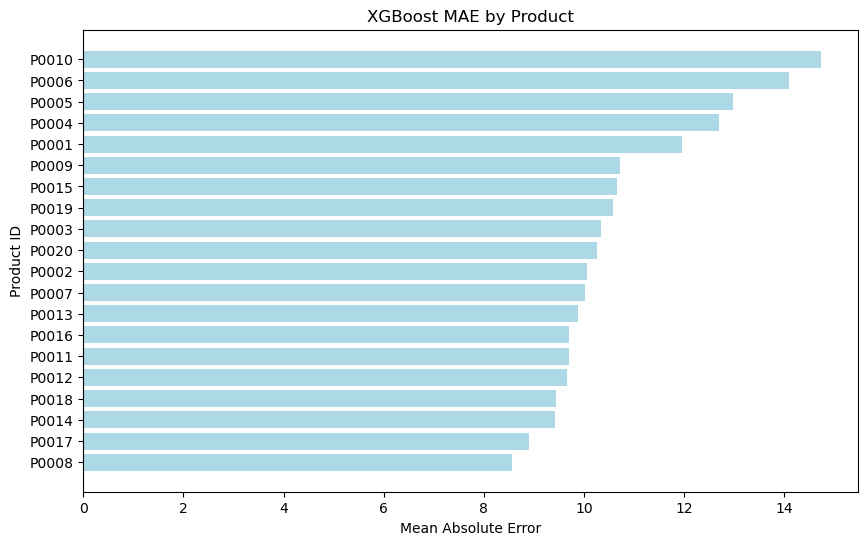

In [103]:
product_metrics_sorted = product_metrics.sort_values(
    "MAE",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    product_metrics_sorted["Product ID"],
    product_metrics_sorted["MAE"], color="lightblue"
)

plt.title("XGBoost MAE by Product")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Product ID")

plt.show()

### Product-Level Performance Results

The product-level evaluation shows that XGBoost performs consistently across the complete product portfolio, although forecasting difficulty varies between products.

`P0008` achieves the strongest performance, with an MAE of approximately 8.56 units and an R² of 0.93. This is consistent with the exploratory analysis, where the product showed relatively stable demand behavior.

In contrast, products such as `P0006` and `P0010` present higher forecasting errors. In particular, `P0006` was previously identified as one of the most volatile products and showed a more complex temporal structure, which helps explain its lower predictive performance.

Despite these differences, all products achieve positive and relatively strong R² values, suggesting that the global model generalizes reasonably well across the 20 product time series.

MAE remains the primary evaluation metric, as percentage-based metrics such as MAPE can become disproportionately large during periods of low demand.

### 7.8 Feature Importance

After evaluating the predictive performance of XGBoost, the next step is to understand which variables contribute most to the model's predictions.

Feature importance provides insight into whether the model relies primarily on recent demand history, rolling statistics, product characteristics, calendar information or commercial variables.

The most relevant features will be analyzed to better understand the main drivers of the forecasting model.

In [104]:
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,Promotion,0.107888
1,Demand_rolling_mean_7,0.060008
2,Category_Groceries,0.047679
3,Product ID_P0013,0.038553
4,Product ID_P0002,0.037325
5,Product ID_P0019,0.036462
6,Seasonality_Summer,0.032094
7,Product ID_P0007,0.031991
8,Product ID_P0009,0.031741
9,Category_Electronics,0.030626


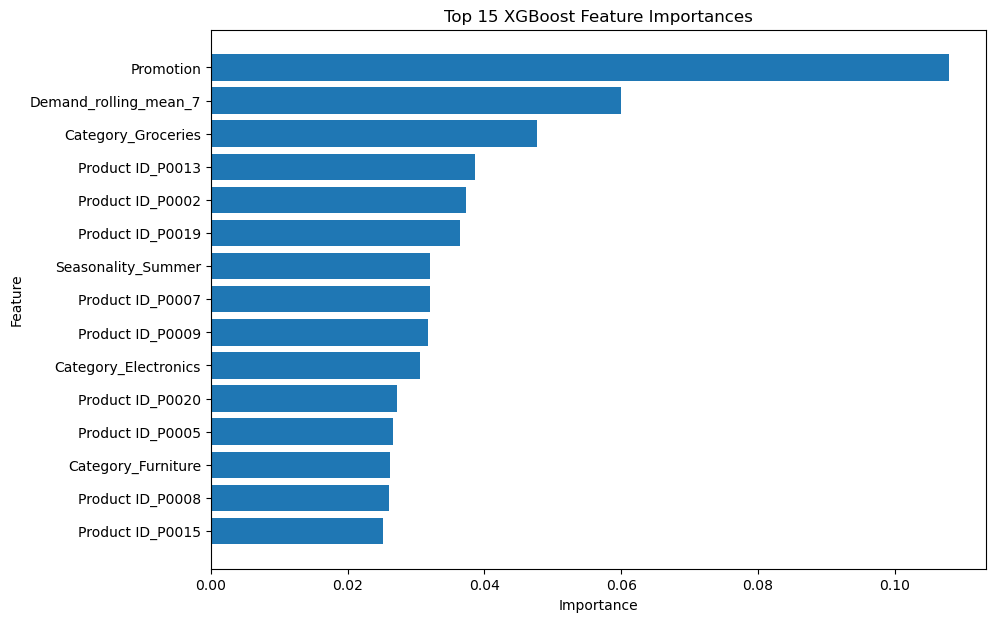

In [105]:
top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Results

The XGBoost feature importance analysis shows that the model combines commercial, temporal and product-specific information when forecasting demand.

`Promotion` is the most influential feature, which is consistent with the exploratory analysis where promotional periods showed substantially higher average demand.

The 7-day rolling mean of demand is the second most relevant predictor, indicating that recent demand levels provide strong information about short-term future demand.

Product and category variables also play an important role, suggesting that the model captures different baseline demand patterns across products and product groups. In particular, `Category_Groceries` and several individual product identifiers appear among the most influential features.

`Seasonality_Summer` also contributes significantly, supporting the seasonal differences observed during the exploratory analysis.

Overall, the results suggest that forecasting performance is driven by a combination of recent demand behavior, promotional activity and product-specific characteristics.

### 7.9 SHAP Model Interpretation

Feature importance identifies which variables are relevant to the XGBoost model, but it does not explain the direction or magnitude of their effect on individual predictions.

SHAP values are therefore used to provide a more detailed interpretation of the model.

This analysis helps understand:

- Which features have the greatest overall impact on predictions.
- Whether high or low feature values tend to increase or decrease predicted demand.
- How the model combines temporal, product and commercial information when generating forecasts.

In [106]:
# Sample test observations
X_shap = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

# Convert data to XGBoost DMatrix
dmat = xgboost.DMatrix(
    X_shap,
    feature_names=X_shap.columns.tolist()
)

# Calculate SHAP contributions directly with XGBoost
shap_contributions = xgb_model.get_booster().predict(
    dmat,
    pred_contribs=True
)

# Last column is the bias/base value
shap_values = shap_contributions[:, :-1]

print(shap_values.shape)

(1000, 63)


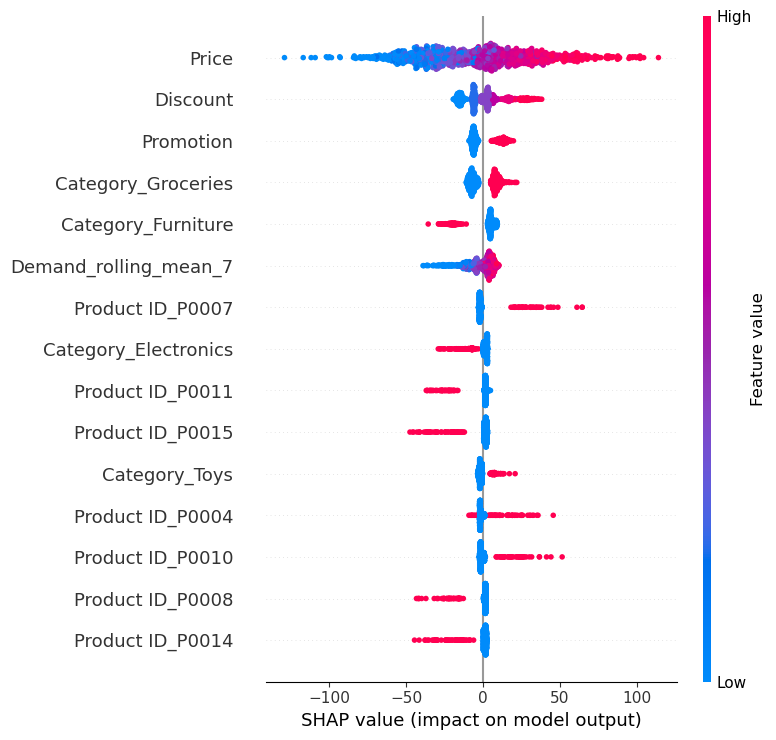

In [107]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

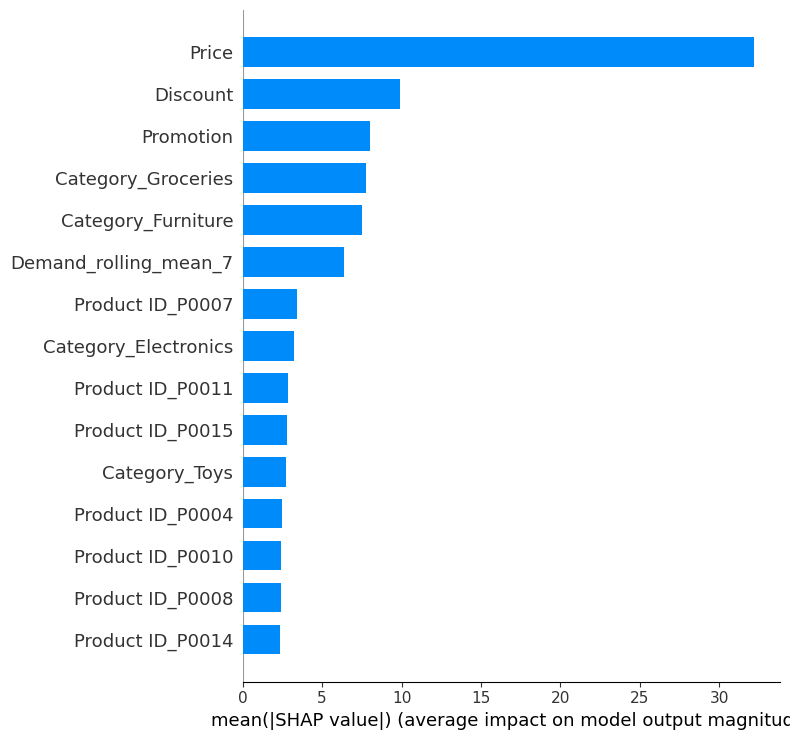

In [108]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15
)

### SHAP Interpretation Results

SHAP analysis provides a more detailed view of how the XGBoost model generates its demand forecasts.

`Price` shows the highest overall impact on model predictions. Higher price values generally push predictions upward, while lower values tend to reduce predicted demand. However, this relationship should not be interpreted causally, since price ranges differ across products and may also capture product-specific demand patterns.

Commercial variables show particularly clear effects. Higher `Discount` values increase predicted demand, while the presence of a `Promotion` also produces a consistently positive contribution. These results are aligned with the patterns observed during the exploratory analysis.

Product characteristics also play an important role. Products belonging to `Groceries` tend to receive higher demand predictions, while `Furniture` has a negative contribution. Individual product identifiers further capture differences in baseline demand between SKUs.

Finally, the `Demand_rolling_mean_7` feature confirms the importance of recent demand behavior, with low recent demand levels generally reducing future predictions.

Overall, SHAP confirms that the model combines recent demand history, commercial conditions and product-specific characteristics when generating forecasts.

### 7.10 Forecast Visualization and Residual Diagnostics

After selecting XGBoost as the best-performing forecasting model, its predictions are analyzed visually and through residual diagnostics.

The objective is to verify whether predicted demand follows the observed demand patterns and to determine whether systematic information remains unexplained by the model.

Residuals are defined as:

**Residual = Actual Demand - Predicted Demand**

A well-performing forecasting model should produce residuals centered around zero with limited temporal dependence and no clear systematic patterns.

In [109]:
test_results["Residual"] = (
    test_results["Demand"] - test_results["Prediction"]
)

print(f"Mean residual: {test_results['Residual'].mean():.2f}")
print(f"Residual std: {test_results['Residual'].std():.2f}")

Mean residual: -0.98
Residual std: 14.03


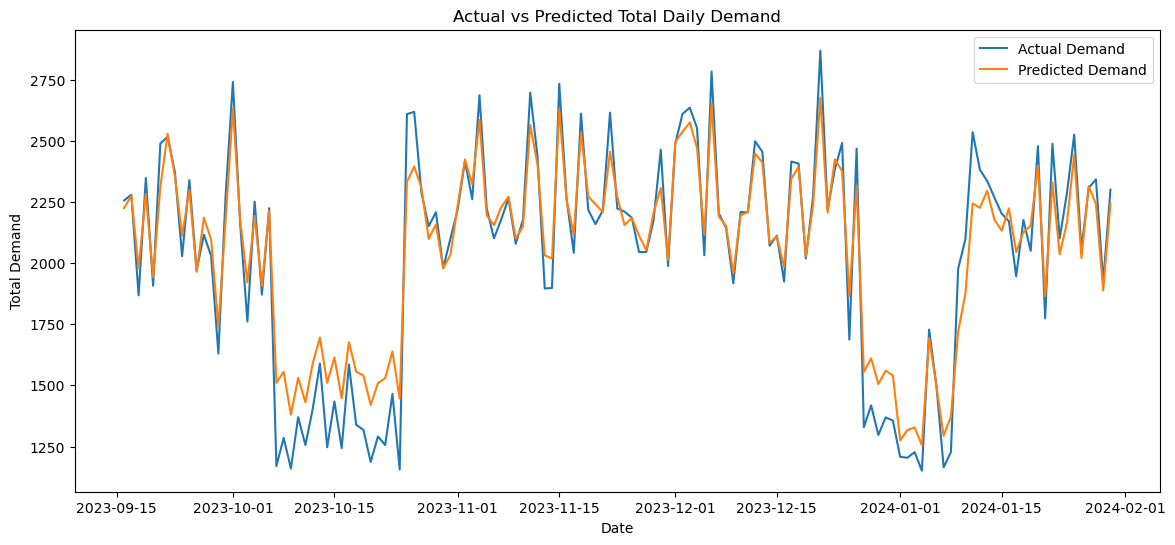

In [110]:
daily_forecast = (
    test_results
    .groupby("Date")[["Demand", "Prediction"]]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    daily_forecast.index,
    daily_forecast["Demand"],
    label="Actual Demand"
)

plt.plot(
    daily_forecast.index,
    daily_forecast["Prediction"],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.legend()

plt.show()

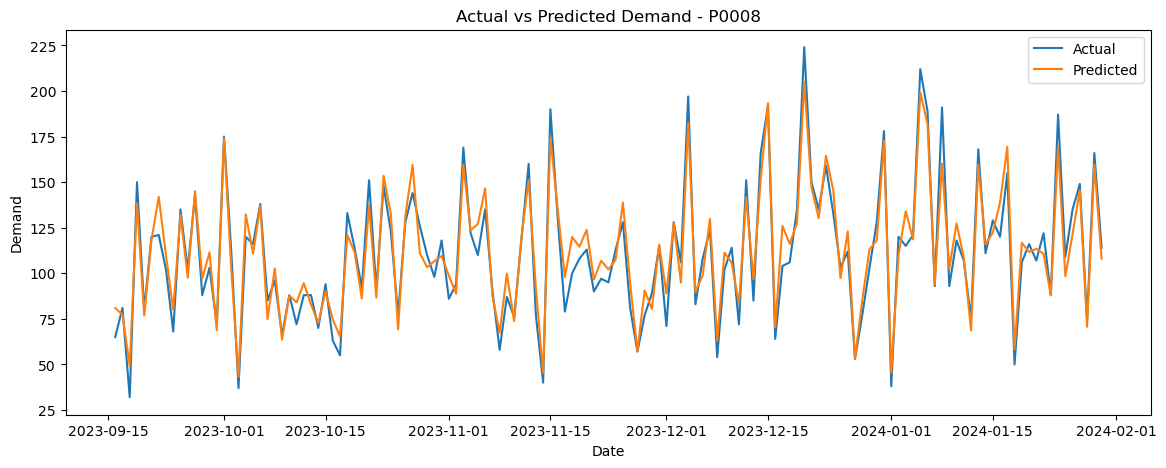

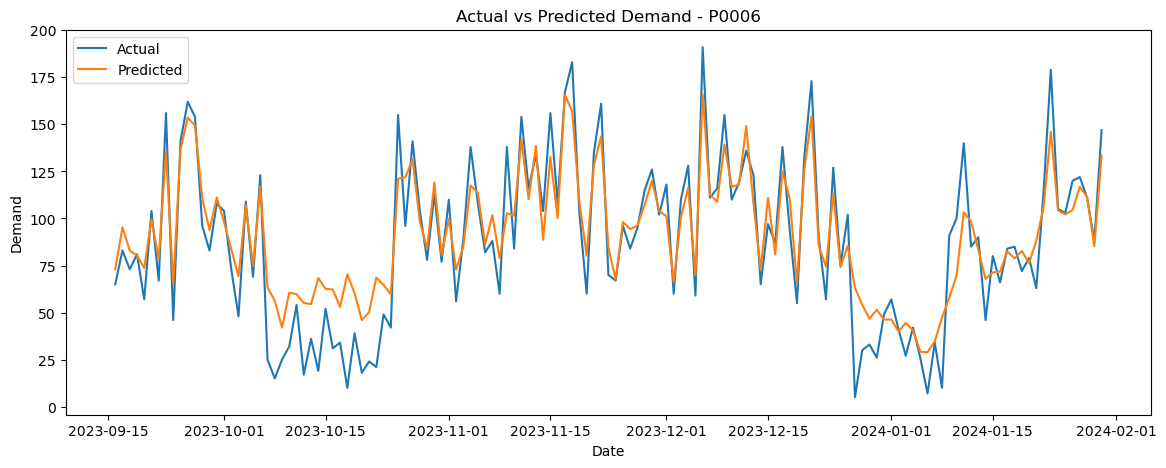

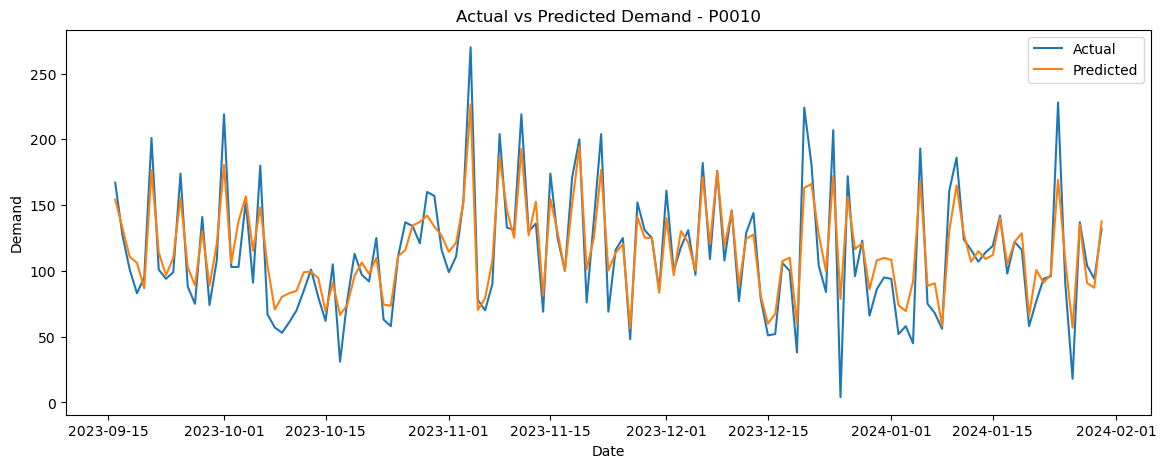

In [111]:
products_to_plot = ["P0008", "P0006", "P0010"]

for product in products_to_plot:

    product_results = (
        test_results[
            test_results["Product ID"] == product
        ]
        .sort_values("Date")
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        product_results["Date"],
        product_results["Demand"],
        label="Actual"
    )

    plt.plot(
        product_results["Date"],
        product_results["Prediction"],
        label="Predicted"
    )

    plt.title(f"Actual vs Predicted Demand - {product}")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()

    plt.show()

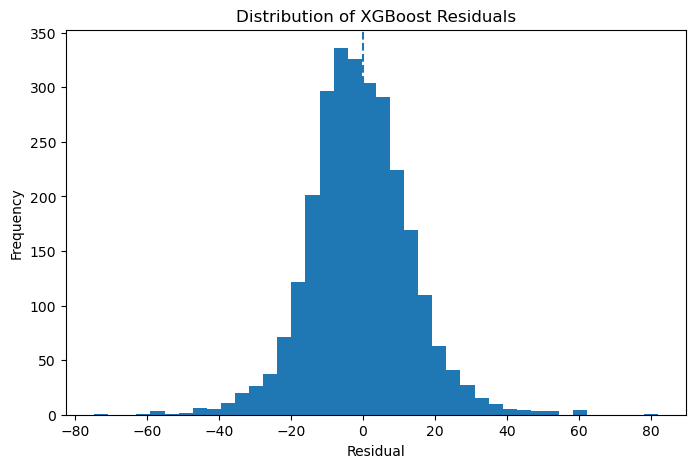

In [112]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_results["Residual"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of XGBoost Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

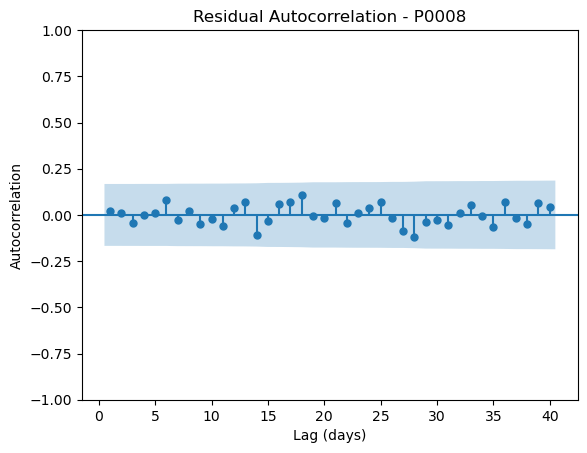

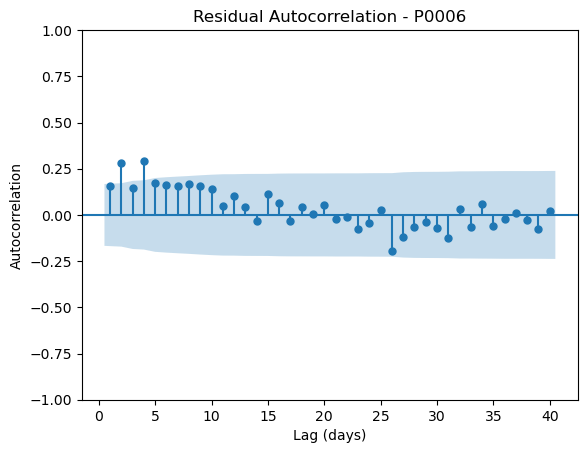

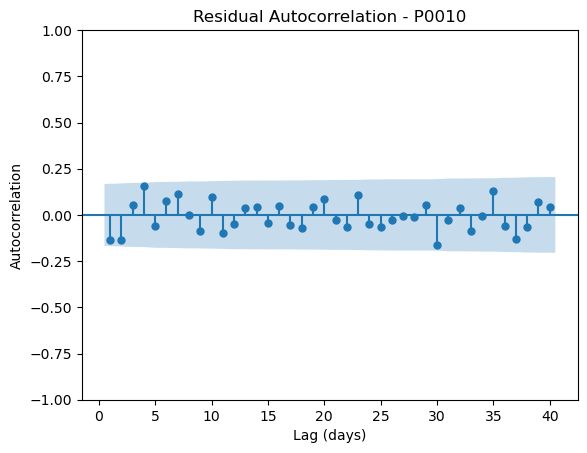

In [113]:
for product in products_to_plot:

    product_residuals = (
        test_results[
            test_results["Product ID"] == product
        ]
        .sort_values("Date")["Residual"]
    )

    plot_acf(
        product_residuals,
        lags=40,
        zero=False
    )

    plt.title(f"Residual Autocorrelation - {product}")
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")

    plt.show()

In [138]:
residual_diagnostics = []

for product in products_to_plot:

    residuals = (
        test_results[
            test_results["Product ID"] == product
        ]
        .sort_values("Date")["Residual"]
    )

    ljung_box = acorr_ljungbox(
        residuals,
        lags=[10],
        return_df=True
    )

    arch_stat, arch_pvalue, _, _ = het_arch(
        residuals,
        nlags=10
    )

    residual_diagnostics.append({
        "Product ID": product,
        "Mean Residual": residuals.mean(),
        "Ljung-Box p-value": ljung_box["lb_pvalue"].iloc[0],
        "ARCH p-value": arch_pvalue
    })

residual_diagnostics = pd.DataFrame(
    residual_diagnostics
)

residual_diagnostics

,Product ID,Mean Residual,Ljung-Box p-value,ARCH p-value
0,P0008,-1.432362,9.973883e-01,0.790614
1,P0006,-3.751774,9.756080e-08,0.017157
2,P0010,-2.311935,1.389950e-01,0.167851


### Forecast and Residual Diagnostic Results

The XGBoost forecasts closely follow the observed demand patterns, both at store level and across individual products. The model successfully captures most changes in demand, although predictions tend to smooth some of the most extreme peaks and troughs.

The overall residual distribution is approximately centered around zero, with a mean residual of -0.98 units, indicating only a small global tendency toward demand overestimation.

Residual diagnostics reveal different behaviors across products:

- `P0008` shows no evidence of residual autocorrelation or conditional heteroskedasticity, suggesting that the model captures its temporal structure effectively.
- `P0010` also presents largely unstructured residuals, despite having a comparatively higher forecasting error.
- `P0006`, however, retains significant residual autocorrelation and ARCH effects. This is consistent with the higher variability and complex temporal structure previously identified during the exploratory analysis.

Overall, XGBoost provides strong and consistent forecasting performance across the product portfolio, although highly volatile products such as `P0006` remain more difficult to model completely.

These residual patterns highlight an important limitation of the model while confirming that most of the predictable structure has been successfully captured for the majority of the analyzed products.

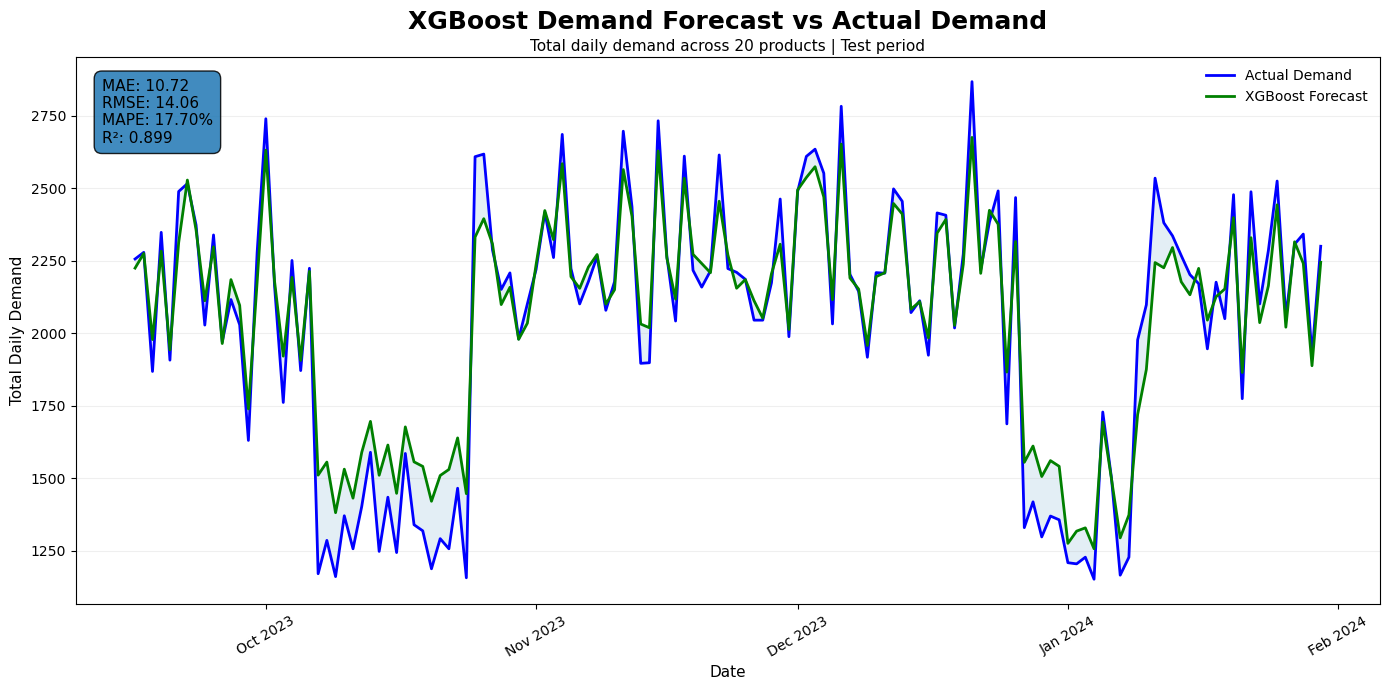

In [116]:
# important graphics

fig, ax = plt.subplots(figsize=(14, 7))

# Actual and predicted demand
ax.plot(
    daily_forecast.index,
    daily_forecast["Demand"],
    label="Actual Demand",
    linewidth=2, color="blue"
)

ax.plot(
    daily_forecast.index,
    daily_forecast["Prediction"],
    label="XGBoost Forecast",
    linewidth=2, color="green"
)

# Highlight forecasting error
ax.fill_between(
    daily_forecast.index,
    daily_forecast["Demand"],
    daily_forecast["Prediction"],
    alpha=0.12
)

# Titles
ax.set_title(
    "XGBoost Demand Forecast vs Actual Demand",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0.5,
    1.01,
    "Total daily demand across 20 products | Test period",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Total Daily Demand", fontsize=11)

# Metrics box
metrics_text = (
    f"MAE: {xgb_mae:.2f}\n"
    f"RMSE: {xgb_rmse:.2f}\n"
    f"MAPE: {xgb_mape:.2f}%\n"
    f"R²: {xgb_r2:.3f}"
)

ax.text(
    0.02,
    0.96,
    metrics_text,
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.85
    )
)

# Date formatting
ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=30)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "xgboost_forecast_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

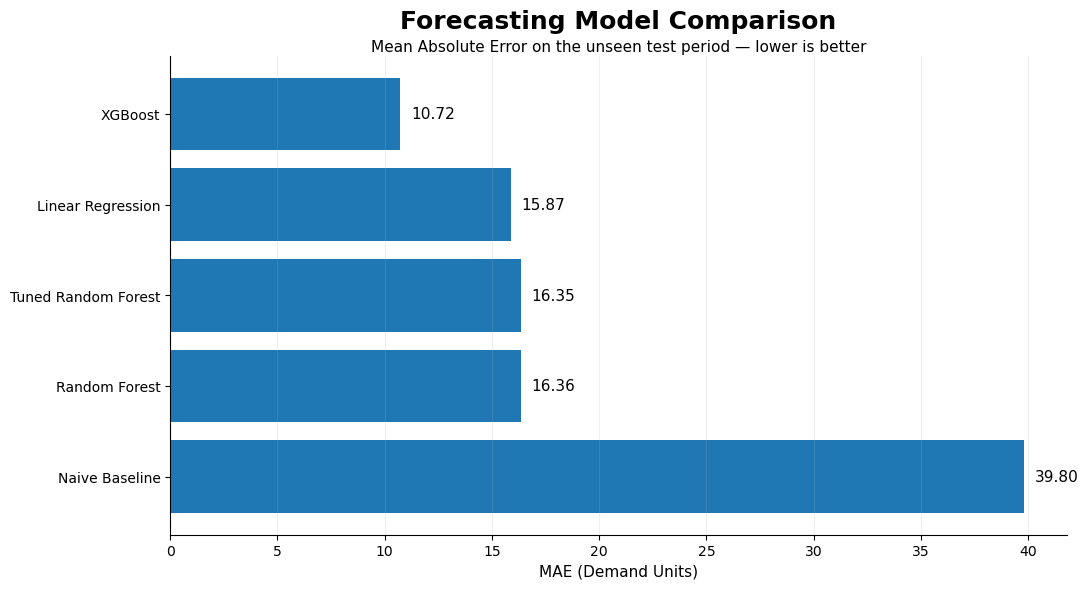

In [117]:
comparison = (
    results
    .sort_values("MAE", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    comparison["Model"],
    comparison["MAE"]
)

ax.invert_yaxis()

# Add values at the end of each bar
for bar, value in zip(bars, comparison["MAE"]):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=11
    )

ax.set_title(
    "Forecasting Model Comparison",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.text(
    0.5,
    1.01,
    "Mean Absolute Error on the unseen test period — lower is better",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

ax.set_xlabel("MAE (Demand Units)", fontsize=11)
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.2
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "forecasting_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Inventory Planning

The demand forecasts can be translated into operational inventory decisions by comparing expected demand with the available stock for each product.

A simple replenishment policy will be developed using:

- XGBoost predicted demand.
- The most recently available inventory level.
- A safety stock component to account for forecasting uncertainty.

The objective is not to build a complete inventory optimization system, since information such as lead times, holding costs and stockout costs is not available. Instead, the analysis demonstrates how demand forecasts can support practical replenishment decisions.

In [118]:
# Previous-day inventory available for each product
df_store["Inventory_lag_1"] = (
    df_store
    .groupby("Product ID")["Inventory Level"]
    .shift(1)
)

### 8.1 Safety Stock Based on Forecast Uncertainty

Forecasting uncertainty differs between products. A stable product such as `P0008` does not require the same inventory buffer as a more volatile and difficult-to-predict product such as `P0006`.

To account for this uncertainty, a product-specific safety stock will be estimated using out-of-sample forecasting errors obtained through temporal cross-validation on the training period.

Residuals are defined as:

**Residual = Actual Demand - Predicted Demand**

Positive residuals represent situations where the model underestimated demand, which are particularly relevant for inventory planning.

The 95th percentile of the historical residual distribution will be used as an illustrative safety stock level for each product. This provides an additional buffer against unusually high demand while avoiding the use of information from the final test period.

In [119]:
train_cv_data = train_data.reset_index(drop=True).copy()

product_cols = [
    col for col in train_cv_data.columns
    if col.startswith("Product ID_")
]

train_cv_data["Product ID"] = (
    train_cv_data[product_cols]
    .idxmax(axis=1)
    .str.replace("Product ID_", "", regex=False)
)

In [121]:
cv_predictions = []

for fold, (train_idx, val_idx) in enumerate(temporal_cv, 1):

    X_fold_train = train_cv_data.loc[
        train_idx, feature_cols
    ]

    y_fold_train = train_cv_data.loc[
        train_idx, "Demand"
    ]

    X_fold_val = train_cv_data.loc[
        val_idx, feature_cols
    ]

    y_fold_val = train_cv_data.loc[
        val_idx, "Demand"
    ]

    fold_model = clone(xgb_model)

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    fold_pred = fold_model.predict(
        X_fold_val
    )

    fold_results = pd.DataFrame({
        "Date": train_cv_data.loc[
            val_idx, "Date"
        ].values,

        "Product ID": train_cv_data.loc[
            val_idx, "Product ID"
        ].values,

        "Demand": y_fold_val.values,

        "Prediction": fold_pred,

        "Fold": fold
    })

    cv_predictions.append(fold_results)

cv_predictions = pd.concat(
    cv_predictions,
    ignore_index=True
)

In [122]:
cv_predictions["Residual"] = (
    cv_predictions["Demand"]
    - cv_predictions["Prediction"]
)

In [123]:
cv_predictions.head()

,Date,Product ID,Demand,Prediction,Fold,Residual
0,2023-03-20,P0001,151,165.971268,1,-14.971268
1,2023-03-21,P0001,75,61.028824,1,13.971176
2,2023-03-22,P0001,47,37.292377,1,9.707623
3,2023-03-23,P0001,130,111.872482,1,18.127518
4,2023-03-24,P0001,138,146.694687,1,-8.694687


In [124]:
# Safety Stock

safety_stock = (
    cv_predictions
    .groupby("Product ID")["Residual"]
    .quantile(0.95)
    .clip(lower=0)
    .round()
    .astype(int)
    .reset_index(name="Safety Stock")
)

safety_stock

,Product ID,Safety Stock
0,P0001,23
1,P0002,33
2,P0003,23
3,P0004,36
4,P0005,28
5,P0006,27
6,P0007,29
7,P0008,18
8,P0009,31
9,P0010,52


### Safety Stock Estimation Results

Product-specific safety stock levels show meaningful differences in forecasting uncertainty.

Products with more stable forecasting behavior generally require smaller buffers, while products with larger historical underestimation errors require higher safety stock levels.

The safety stock does not depend on average forecasting error alone. Instead, it focuses on the upper tail of positive residuals, representing situations where actual demand exceeded the forecast.

This makes the buffer specifically oriented toward reducing the operational risk of demand underestimation.

### 8.2 Replenishment Recommendation

In [125]:
inventory_data = (
    df_store
    .sort_values(["Product ID", "Date"])
    [["Date", "Product ID", "Inventory Level"]]
    .copy()
)

inventory_data["Inventory_lag_1"] = (
    inventory_data
    .groupby("Product ID")["Inventory Level"]
    .shift(1)
)

In [126]:
inventory_test = inventory_data[
    ["Date", "Product ID", "Inventory_lag_1"]
]

test_inventory = test_results.merge(
    inventory_test,
    on=["Date", "Product ID"],
    how="left"
)

In [127]:
test_inventory = test_inventory.merge(
    safety_stock,
    on="Product ID",
    how="left"
)

In [128]:
test_inventory[
    [
        "Date",
        "Product ID",
        "Demand",
        "Prediction",
        "Inventory_lag_1",
        "Safety Stock"
    ]
].head()

,Date,Product ID,Demand,Prediction,Inventory_lag_1,Safety Stock
0,2023-09-16,P0001,121,109.994125,205.0,23
1,2023-09-17,P0001,126,125.120773,47.0,23
2,2023-09-18,P0001,38,42.338047,370.0,23
3,2023-09-19,P0001,157,135.794556,288.0,23
4,2023-09-20,P0001,110,113.023552,246.0,23


In [129]:
test_inventory["Target Stock"] = (
    test_inventory["Prediction"]
    + test_inventory["Safety Stock"]
)

In [130]:
test_inventory["Recommended Order"] = np.ceil(
    (
        test_inventory["Target Stock"]
        - test_inventory["Inventory_lag_1"]
    ).clip(lower=0)
).astype(int)

In [131]:
test_inventory[
    [
        "Date",
        "Product ID",
        "Prediction",
        "Safety Stock",
        "Inventory_lag_1",
        "Target Stock",
        "Recommended Order"
    ]
].head(20)

,Date,Product ID,Prediction,Safety Stock,Inventory_lag_1,Target Stock,Recommended Order
0,2023-09-16,P0001,109.994125,23,205.0,132.994125,0
1,2023-09-17,P0001,125.120773,23,47.0,148.120773,102
2,2023-09-18,P0001,42.338047,23,370.0,65.338047,0
3,2023-09-19,P0001,135.794556,23,288.0,158.794556,0
4,2023-09-20,P0001,113.023552,23,246.0,136.023552,0
5,2023-09-21,P0001,54.945473,23,96.0,77.945473,0
6,2023-09-22,P0001,127.022087,23,356.0,150.022087,0
7,2023-09-23,P0001,111.678780,23,282.0,134.678780,0
8,2023-09-24,P0001,95.773895,23,149.0,118.773895,0
9,2023-09-25,P0001,79.289917,23,303.0,102.289917,0


### 8.3 Replenishment Policy Evaluation

The proposed replenishment policy is evaluated retrospectively using the actual demand observed during the test period.

Two strategies will be compared:

1. **Forecast-only policy:** replenishment is based exclusively on predicted demand.
2. **Forecast + Safety Stock policy:** replenishment additionally includes the product-specific safety stock estimated from historical forecasting uncertainty.

For each strategy, the analysis evaluates whether the resulting stock would have been sufficient to cover actual demand, as well as the amount of remaining inventory after demand is fulfilled.

Since supplier lead times are not available in the dataset, the simulation assumes that recommended replenishment is available before the corresponding day's demand occurs. Therefore, the results should be interpreted as an illustrative inventory-planning scenario rather than a complete operational replenishment system.

In [132]:
test_inventory["Order_No_Safety"] = np.ceil(
    (
        test_inventory["Prediction"]
        - test_inventory["Inventory_lag_1"]
    ).clip(lower=0)
).astype(int)

In [133]:
# Available stock after replenishment

test_inventory["Available_No_Safety"] = (
    test_inventory["Inventory_lag_1"]
    + test_inventory["Order_No_Safety"]
)

test_inventory["Available_With_Safety"] = (
    test_inventory["Inventory_lag_1"]
    + test_inventory["Recommended Order"]
)

In [134]:
test_inventory["Shortage_No_Safety"] = (
    test_inventory["Demand"]
    - test_inventory["Available_No_Safety"]
).clip(lower=0)

test_inventory["Excess_No_Safety"] = (
    test_inventory["Available_No_Safety"]
    - test_inventory["Demand"]
).clip(lower=0)

In [135]:
test_inventory["Shortage_With_Safety"] = (
    test_inventory["Demand"]
    - test_inventory["Available_With_Safety"]
).clip(lower=0)

test_inventory["Excess_With_Safety"] = (
    test_inventory["Available_With_Safety"]
    - test_inventory["Demand"]
).clip(lower=0)

In [136]:
# Business metrics

def inventory_metrics(
    df,
    order_col,
    shortage_col,
    excess_col
):
    return {
        "Service Level (%)": (
            (df[shortage_col] == 0).mean() * 100
        ),
        "Total Shortage": df[shortage_col].sum(),
        "Average Excess Stock": df[excess_col].mean(),
        "Total Ordered": df[order_col].sum()
    }

In [137]:
policy_comparison = pd.DataFrame([
    {
        "Policy": "Forecast Only",
        **inventory_metrics(
            test_inventory,
            "Order_No_Safety",
            "Shortage_No_Safety",
            "Excess_No_Safety"
        )
    },
    {
        "Policy": "Forecast + Safety Stock",
        **inventory_metrics(
            test_inventory,
            "Recommended Order",
            "Shortage_With_Safety",
            "Excess_With_Safety"
        )
    }
])

policy_comparison

,Policy,Service Level (%),Total Shortage,Average Excess Stock,Total Ordered
0,Forecast Only,91.094891,3200.0,217.241606,14065
1,Forecast + Safety Stock,98.795620,226.0,221.127007,27685


### Replenishment Policy Results

The addition of product-specific safety stock substantially improves inventory availability during the test period.

Compared with a forecast-only replenishment strategy:

- Service level increases from **91.09% to 98.80%**.
- Total shortage decreases from **3,200 to 226 units**, representing a reduction of approximately **92.9%**.
- Average excess stock increases only moderately from **217.24 to 221.13 units per product-day**.
- Total ordered volume increases from **14,065 to 27,685 units**.

These results illustrate the fundamental inventory trade-off between service level and stock exposure. A higher safety buffer dramatically reduces stockout risk, but requires significantly greater replenishment volumes and generates additional excess inventory.

Since holding costs, stockout costs and supplier lead times are not available, the proposed policy should not be interpreted as economically optimal. Instead, it demonstrates how forecast uncertainty can be translated into practical inventory-planning decisions.

### 8.4 Safety Stock Sensitivity Analysis

The previous replenishment policy used the 95th percentile of historical forecast residuals as a product-specific safety stock.

However, a higher safety stock improves product availability at the cost of greater inventory exposure and replenishment volume.

To analyze this trade-off, several safety stock levels will be evaluated using residual percentiles of 50%, 75%, 90%, 95% and 99%, together with a forecast-only policy with no safety stock.

For each policy, service level, total shortage, average excess stock and total ordered volume will be compared. This sensitivity analysis helps identify a more balanced inventory policy rather than selecting a safety stock level arbitrarily.

In [138]:
inventory_evaluation = test_results.merge(
    inventory_test,
    on=["Date", "Product ID"],
    how="left"
)

In [139]:
safety_percentiles = [0, 0.50, 0.75, 0.90, 0.95, 0.99]

policy_results = []

for q in safety_percentiles:

    policy_data = inventory_evaluation.copy()

    # Forecast-only policy
    if q == 0:
        policy_data["Safety Stock"] = 0
        policy_name = "No Safety Stock"

    else:
        # Product-specific safety stock
        safety_q = (
            cv_predictions
            .groupby("Product ID")["Residual"]
            .quantile(q)
            .clip(lower=0)
            .round()
        )

        policy_data["Safety Stock"] = (
            policy_data["Product ID"]
            .map(safety_q)
        )

        policy_name = f"{int(q * 100)}th Percentile"

    # Target inventory
    policy_data["Target Stock"] = (
        policy_data["Prediction"]
        + policy_data["Safety Stock"]
    )

    # Recommended replenishment
    policy_data["Recommended Order"] = np.ceil(
        (
            policy_data["Target Stock"]
            - policy_data["Inventory_lag_1"]
        ).clip(lower=0)
    )

    # Available inventory after replenishment
    policy_data["Available Stock"] = (
        policy_data["Inventory_lag_1"]
        + policy_data["Recommended Order"]
    )

    # Stockout and excess inventory
    policy_data["Shortage"] = (
        policy_data["Demand"]
        - policy_data["Available Stock"]
    ).clip(lower=0)

    policy_data["Excess Stock"] = (
        policy_data["Available Stock"]
        - policy_data["Demand"]
    ).clip(lower=0)

    # Metrics
    policy_results.append({
        "Policy": policy_name,
        "Percentile": q * 100,
        "Average Safety Stock": policy_data["Safety Stock"].mean(),
        "Service Level (%)": (
            (policy_data["Shortage"] == 0).mean() * 100
        ),
        "Total Shortage": policy_data["Shortage"].sum(),
        "Average Excess Stock": policy_data["Excess Stock"].mean(),
        "Total Ordered": policy_data["Recommended Order"].sum()
    })

In [140]:
safety_analysis = pd.DataFrame(policy_results)

safety_analysis

,Policy,Percentile,Average Safety Stock,Service Level (%),Total Shortage,Average Excess Stock,Total Ordered
0,No Safety Stock,0.0,0.00,91.094891,3200.0,217.241606,14065.0
1,50th Percentile,50.0,0.55,91.313869,3033.0,217.291606,14369.0
2,75th Percentile,75.0,9.60,94.744526,1409.0,218.115328,18250.0
3,90th Percentile,90.0,18.55,97.481752,536.0,219.505474,22932.0
4,95th Percentile,95.0,25.50,98.795620,226.0,221.127007,27685.0
5,99th Percentile,99.0,43.70,99.817518,35.0,226.504015,42609.0


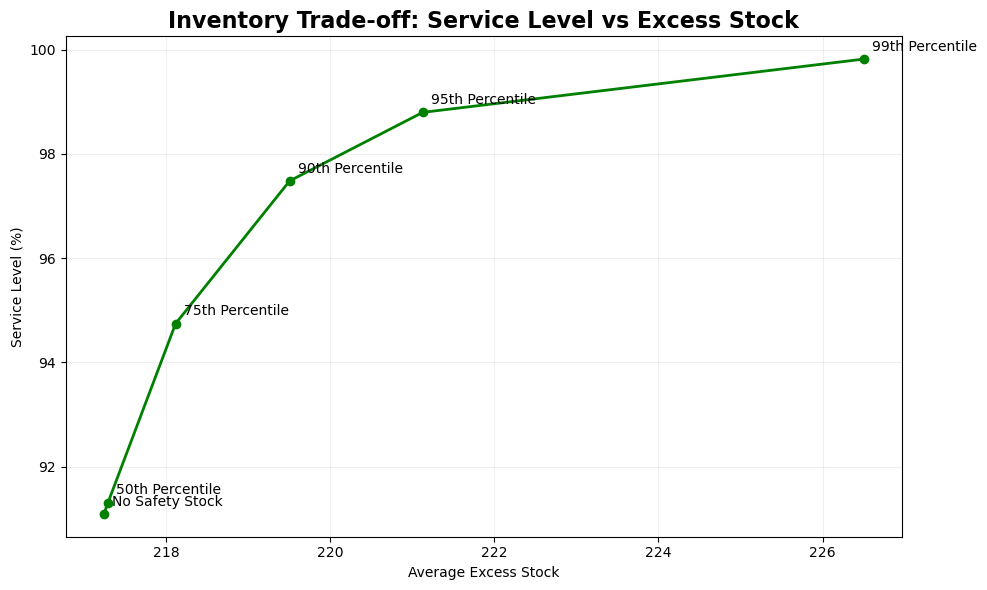

In [142]:
plt.figure(figsize=(10, 6))

plt.plot(
    safety_analysis["Average Excess Stock"],
    safety_analysis["Service Level (%)"],
    marker="o",
    linewidth=2, color="green"
)

for _, row in safety_analysis.iterrows():

    plt.annotate(
        row["Policy"],
        (
            row["Average Excess Stock"],
            row["Service Level (%)"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title(
    "Inventory Trade-off: Service Level vs Excess Stock",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Excess Stock")
plt.ylabel("Service Level (%)")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Safety Stock Sensitivity Results

The sensitivity analysis reveals a clear trade-off between product availability and inventory exposure.

Increasing the safety stock progressively improves service level and reduces shortages. However, the marginal benefit decreases as increasingly conservative percentiles are used.

The `95th percentile` provides a particularly balanced result:

- Service level: **98.80%**
- Total shortage: **226 units**
- Average excess stock: **221.13 units**
- Total ordered volume: **27,685 units**

Increasing the buffer further to the `99th percentile` raises service level to 99.82%, but requires substantially more replenishment and increases excess inventory considerably.

Therefore, the 95th percentile is selected as the final illustrative safety stock policy. It provides a high level of product availability while avoiding the significantly larger inventory exposure required by the most conservative strategy.

This choice should be interpreted as a service-oriented operational recommendation rather than an economically optimal inventory policy, since holding costs, stockout costs and supplier lead times are not available.

### 8.5 Forecast-Based ABC Inventory Classification

As a final inventory prioritization step, the 20 products are classified using an ABC analysis based on their forecasted demand during the test period.

Unlike a traditional ABC classification based on annual consumption value, this analysis uses predicted demand volume. Therefore, the objective is to identify which products are expected to concentrate the largest share of future operational demand.

Products are ranked according to their total forecasted demand and grouped as:

- **Class A:** products accounting for approximately the first 80% of forecasted demand.
- **Class B:** products accounting for the next 15%, up to approximately 95%.
- **Class C:** products representing the remaining demand.

This classification can support differentiated inventory priorities, with greater monitoring and replenishment attention given to products that contribute most to expected demand.

In [143]:
abc_analysis = (
    test_results
    .groupby("Product ID")["Prediction"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

abc_analysis = abc_analysis.rename(
    columns={"Prediction": "Forecast Demand"}
)

In [144]:
abc_analysis["Demand Share"] = (
    abc_analysis["Forecast Demand"]
    / abc_analysis["Forecast Demand"].sum()
)

abc_analysis["Cumulative Share"] = (
    abc_analysis["Demand Share"].cumsum()
)

In [145]:
abc_analysis["Previous Cumulative"] = (
    abc_analysis["Cumulative Share"]
    .shift(1, fill_value=0)
)

abc_analysis["ABC Class"] = np.select(
    [
        abc_analysis["Previous Cumulative"] < 0.80,
        abc_analysis["Previous Cumulative"] < 0.95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

abc_analysis = abc_analysis.drop(
    columns="Previous Cumulative"
)

abc_analysis

,Product ID,Forecast Demand,Demand Share,Cumulative Share,ABC Class
0,P0004,16108.468750,0.057221,0.057221,A
1,P0010,15880.735352,0.056412,0.113633,A
2,P0009,15878.050781,0.056402,0.170035,A
3,P0014,15781.000977,0.056058,0.226093,A
4,P0007,15686.625977,0.055722,0.281815,A
5,P0020,15556.506836,0.055260,0.337075,A
6,P0019,15554.202148,0.055252,0.392327,A
7,P0008,15355.233398,0.054545,0.446873,A
8,P0013,15354.963867,0.054544,0.501417,A
9,P0002,15178.133789,0.053916,0.555333,A


In [146]:
abc_display = abc_analysis.copy()

abc_display["Demand Share (%)"] = (
    abc_display["Demand Share"] * 100
)

abc_display["Cumulative Share (%)"] = (
    abc_display["Cumulative Share"] * 100
)

abc_display[
    [
        "Product ID",
        "Forecast Demand",
        "Demand Share (%)",
        "Cumulative Share (%)",
        "ABC Class"
    ]
]

,Product ID,Forecast Demand,Demand Share (%),Cumulative Share (%),ABC Class
0,P0004,16108.468750,5.722088,5.722088,A
1,P0010,15880.735352,5.641191,11.363279,A
2,P0009,15878.050781,5.640238,17.003517,A
3,P0014,15781.000977,5.605763,22.609280,A
4,P0007,15686.625977,5.572240,28.181520,A
5,P0020,15556.506836,5.526019,33.707539,A
6,P0019,15554.202148,5.525200,39.232738,A
7,P0008,15355.233398,5.454522,44.687260,A
8,P0013,15354.963867,5.454426,50.141685,A
9,P0002,15178.133789,5.391612,55.533295,A


In [147]:
abc_summary = (
    abc_analysis
    .groupby("ABC Class")
    .agg(
        Products=("Product ID", "count"),
        Forecast_Demand=("Forecast Demand", "sum"),
        Demand_Share=("Demand Share", "sum")
    )
    .reindex(["A", "B", "C"])
)

abc_summary["Demand Share (%)"] = (
    abc_summary["Demand_Share"] * 100
)

abc_summary[
    [
        "Products",
        "Forecast_Demand",
        "Demand Share (%)"
    ]
]

,Products,Forecast_Demand,Demand Share (%)
ABC Class,,,
A,15,226393.828125,80.420143
B,4,44914.777344,15.954731
C,1,10205.221680,3.625123


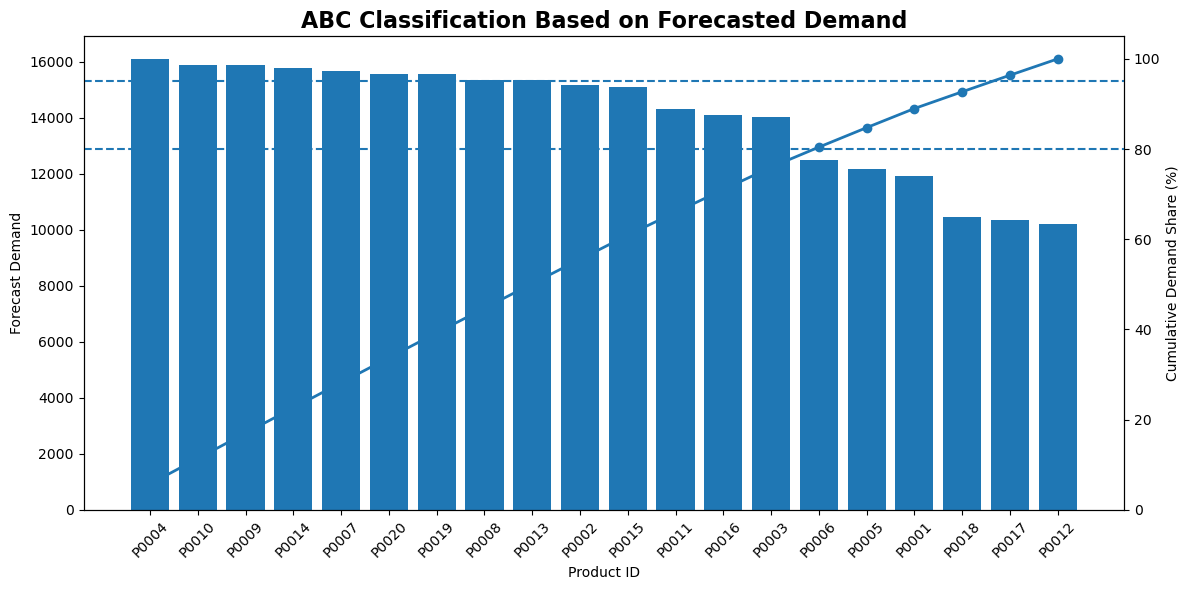

In [148]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(abc_analysis))

# Forecast demand bars
ax1.bar(
    x,
    abc_analysis["Forecast Demand"]
)

ax1.set_xlabel("Product ID")
ax1.set_ylabel("Forecast Demand")

ax1.set_xticks(x)
ax1.set_xticklabels(
    abc_analysis["Product ID"],
    rotation=45
)

# Cumulative demand line
ax2 = ax1.twinx()

ax2.plot(
    x,
    abc_analysis["Cumulative Share"] * 100,
    marker="o",
    linewidth=2
)

ax2.axhline(
    80,
    linestyle="--"
)

ax2.axhline(
    95,
    linestyle="--"
)

ax2.set_ylabel("Cumulative Demand Share (%)")
ax2.set_ylim(0, 105)

plt.title(
    "ABC Classification Based on Forecasted Demand",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [149]:
abc_recommendations = pd.DataFrame({
    "ABC Class": ["A", "B", "C"],
    "Priority": ["High", "Medium", "Low"],
    "Inventory Strategy": [
        "Frequent monitoring and high replenishment priority",
        "Regular monitoring and standard replenishment",
        "Lower monitoring frequency and more conservative stock allocation"
    ]
})

abc_recommendations

,ABC Class,Priority,Inventory Strategy
0,A,High,Frequent monitoring and high replenishment pri...
1,B,Medium,Regular monitoring and standard replenishment
2,C,Low,Lower monitoring frequency and more conservati...


### ABC Classification Results

The forecast-based ABC analysis reveals a relatively balanced distribution of demand across the product portfolio.

Class A contains 15 of the 20 products and represents approximately 80.4% of total forecasted demand. Class B contains four products (16.0%), while only one product is classified as C (3.6%).

Unlike a typical Pareto-type inventory portfolio, demand is therefore not strongly concentrated in a small number of products. Most products contribute meaningfully to total expected demand.

As a result, an ABC classification based exclusively on forecasted demand volume provides limited differentiation for inventory prioritization.

### 8.6 Value-Based ABC Classification

The previous ABC analysis based exclusively on forecasted demand volume showed limited differentiation, as demand was relatively evenly distributed across the product portfolio.

To incorporate the economic importance of each product, a second ABC classification is performed using forecasted sales value:

**Forecasted Sales Value = Predicted Demand × Price**

Products are ranked according to their total expected sales value during the test period and classified using the same cumulative thresholds:

- **Class A:** approximately the first 80% of forecasted sales value.
- **Class B:** the following 15%, up to approximately 95%.
- **Class C:** the remaining value.

Since the dataset provides selling prices rather than unit costs, this classification should be interpreted as a commercial-value prioritization rather than a traditional inventory-cost ABC analysis.

In [150]:
price_data = df_store[
    ["Date", "Product ID", "Price"]
].copy()

value_abc_data = test_results.merge(
    price_data,
    on=["Date", "Product ID"],
    how="left"
)

value_abc_data[
    ["Date", "Product ID", "Prediction", "Price"]
].head()

,Date,Product ID,Prediction,Price
0,2023-09-16,P0001,109.994125,18.28
1,2023-09-17,P0001,125.120773,17.56
2,2023-09-18,P0001,42.338047,11.48
3,2023-09-19,P0001,135.794556,15.23
4,2023-09-20,P0001,113.023552,17.65


In [151]:
print("Missing prices:", value_abc_data["Price"].isna().sum())

Missing prices: 0


In [152]:
value_abc_data["Forecast Sales Value"] = (
    value_abc_data["Prediction"]
    * value_abc_data["Price"]
)

In [153]:
value_abc = (
    value_abc_data
    .groupby("Product ID")["Forecast Sales Value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [154]:
value_abc["Value Share"] = (
    value_abc["Forecast Sales Value"]
    / value_abc["Forecast Sales Value"].sum()
)

value_abc["Cumulative Share"] = (
    value_abc["Value Share"].cumsum()
)

In [155]:
value_abc["Previous Cumulative"] = (
    value_abc["Cumulative Share"]
    .shift(1, fill_value=0)
)

value_abc["ABC Class"] = np.select(
    [
        value_abc["Previous Cumulative"] < 0.80,
        value_abc["Previous Cumulative"] < 0.95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

value_abc = value_abc.drop(
    columns="Previous Cumulative"
)

In [156]:
value_abc_display = value_abc.copy()

value_abc_display["Value Share (%)"] = (
    value_abc_display["Value Share"] * 100
)

value_abc_display["Cumulative Share (%)"] = (
    value_abc_display["Cumulative Share"] * 100
)

value_abc_display[
    [
        "Product ID",
        "Forecast Sales Value",
        "Value Share (%)",
        "Cumulative Share (%)",
        "ABC Class"
    ]
]

,Product ID,Forecast Sales Value,Value Share (%),Cumulative Share (%),ABC Class
0,P0008,1.777864e+06,8.985674,8.985674,A
1,P0011,1.766932e+06,8.930422,17.916096,A
2,P0014,1.507080e+06,7.617079,25.533175,A
3,P0015,1.479832e+06,7.479364,33.012539,A
4,P0016,1.399308e+06,7.072379,40.084918,A
5,P0018,1.335834e+06,6.751569,46.836487,A
6,P0003,1.255630e+06,6.346204,53.182691,A
7,P0017,1.194702e+06,6.038259,59.220950,A
8,P0020,1.173615e+06,5.931684,65.152634,A
9,P0013,1.123099e+06,5.676364,70.828997,A


In [157]:
value_abc_summary = (
    value_abc
    .groupby("ABC Class")
    .agg(
        Products=("Product ID", "count"),
        Forecast_Sales_Value=("Forecast Sales Value", "sum"),
        Value_Share=("Value Share", "sum")
    )
    .reindex(["A", "B", "C"])
)

value_abc_summary["Value Share (%)"] = (
    value_abc_summary["Value_Share"] * 100
)

value_abc_summary[
    [
        "Products",
        "Forecast_Sales_Value",
        "Value Share (%)"
    ]
]

,Products,Forecast_Sales_Value,Value Share (%)
ABC Class,,,
A,12,1.585950e+07,80.157053
B,5,3.211865e+06,16.233402
C,3,7.141678e+05,3.609545


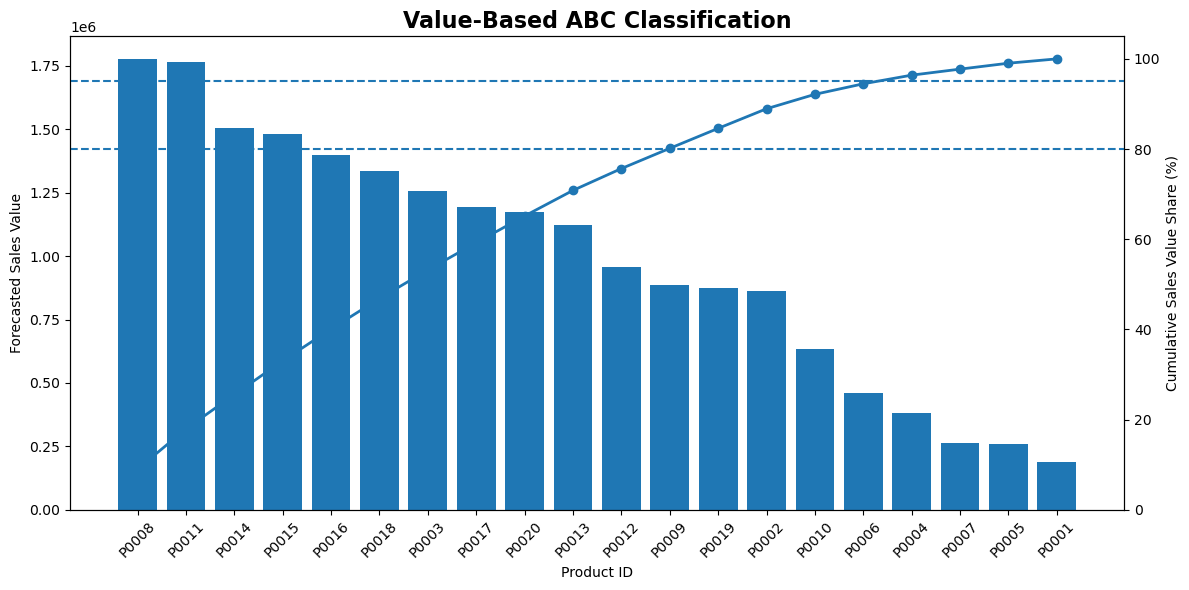

In [158]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(value_abc))

ax1.bar(
    x,
    value_abc["Forecast Sales Value"]
)

ax1.set_xlabel("Product ID")
ax1.set_ylabel("Forecasted Sales Value")

ax1.set_xticks(x)
ax1.set_xticklabels(
    value_abc["Product ID"],
    rotation=45
)

ax2 = ax1.twinx()

ax2.plot(
    x,
    value_abc["Cumulative Share"] * 100,
    marker="o",
    linewidth=2
)

ax2.axhline(80, linestyle="--")
ax2.axhline(95, linestyle="--")

ax2.set_ylabel("Cumulative Sales Value Share (%)")
ax2.set_ylim(0, 105)

plt.title(
    "Value-Based ABC Classification",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Value-Based ABC Results

The value-based ABC classification provides a more meaningful differentiation than the previous demand-volume classification.

Using forecasted sales value, calculated as predicted demand multiplied by product price:

- **Class A:** 12 products representing approximately **80.2%** of forecasted sales value.
- **Class B:** 5 products representing approximately **16.2%**.
- **Class C:** 3 products representing approximately **3.6%**.

The ranking differs considerably from the demand-volume classification, showing that high-demand products are not necessarily the products with the highest expected commercial value.

For example, products such as `P0008` and `P0011` become particularly important once both expected demand and price are considered.

This value-based classification therefore provides a more useful basis for inventory prioritization, allowing greater operational attention to be allocated to products with the highest expected commercial relevance.

### 8.7 ABC Classification and Forecast Uncertainty

As a final inventory prioritization step, the value-based ABC classification is combined with product-specific forecasting uncertainty.

Absolute safety stock levels are normalized by average predicted demand to make uncertainty comparable across products:

**Safety Stock Ratio = Safety Stock / Average Forecast Demand**

Products are then classified into low, medium and high uncertainty groups.

This provides an additional operational perspective: products with high expected commercial value and high forecasting uncertainty require greater monitoring, since errors in their demand forecasts may have a larger business impact.

In [159]:
avg_forecast = (
    test_results
    .groupby("Product ID")["Prediction"]
    .mean()
    .reset_index(name="Average Forecast Demand")
)

In [160]:
inventory_priority = (
    value_abc[
        ["Product ID", "Forecast Sales Value", "ABC Class"]
    ]
    .merge(
        safety_stock,
        on="Product ID",
        how="left"
    )
    .merge(
        avg_forecast,
        on="Product ID",
        how="left"
    )
)

In [161]:
inventory_priority["Safety Stock Ratio (%)"] = (
    inventory_priority["Safety Stock"]
    / inventory_priority["Average Forecast Demand"]
    * 100
)

In [162]:
inventory_priority["Forecast Uncertainty"] = pd.qcut(
    inventory_priority["Safety Stock Ratio (%)"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [163]:
def operational_priority(row):

    abc = row["ABC Class"]
    uncertainty = row["Forecast Uncertainty"]

    if abc == "A" and uncertainty == "High":
        return "Critical"

    elif abc == "A":
        return "High"

    elif abc == "B" and uncertainty == "High":
        return "High"

    elif abc == "B":
        return "Medium"

    elif abc == "C" and uncertainty == "High":
        return "Medium"

    else:
        return "Low"

In [164]:
inventory_priority["Operational Priority"] = (
    inventory_priority.apply(
        operational_priority,
        axis=1
    )
)

In [165]:
priority_order = {
    "Critical": 0,
    "High": 1,
    "Medium": 2,
    "Low": 3
}

inventory_priority["Priority Order"] = (
    inventory_priority["Operational Priority"]
    .map(priority_order)
)

inventory_priority = (
    inventory_priority
    .sort_values(
        ["Priority Order", "Forecast Sales Value"],
        ascending=[True, False]
    )
    .drop(columns="Priority Order")
    .reset_index(drop=True)
)

inventory_priority[
    [
        "Product ID",
        "ABC Class",
        "Average Forecast Demand",
        "Safety Stock",
        "Safety Stock Ratio (%)",
        "Forecast Uncertainty",
        "Operational Priority"
    ]
]

,Product ID,ABC Class,Average Forecast Demand,Safety Stock,Safety Stock Ratio (%),Forecast Uncertainty,Operational Priority
0,P0009,A,115.898178,31,26.747616,High,Critical
1,P0008,A,112.081993,18,16.059672,Low,High
2,P0011,A,104.559258,17,16.258723,Low,High
3,P0014,A,115.189789,19,16.494518,Low,High
4,P0015,A,110.225487,23,20.866317,Low,High
5,P0016,A,103.033875,25,24.263865,Medium,High
6,P0018,A,76.268799,17,22.289587,Low,High
7,P0003,A,102.348679,23,22.472200,Medium,High
8,P0017,A,75.562363,17,22.497973,Medium,High
9,P0020,A,113.551147,21,18.493869,Low,High


### ABC and Forecast Uncertainty Results

Combining the value-based ABC classification with forecast uncertainty provides a more operationally meaningful inventory prioritization.

`P0009` is identified as the only **Critical** product, as it belongs to Class A while also presenting high relative forecasting uncertainty. This combination of high expected commercial value and greater demand uncertainty makes it particularly relevant for close inventory monitoring.

Most other Class A products are classified as **High Priority**, although their forecasting uncertainty is generally low or medium. These products remain economically important but are comparatively easier to manage.

Several Class B products, including `P0010`, `P0004`, `P0002`, `P0006` and `P0019`, show high forecasting uncertainty. `P0010` is especially notable, with a safety stock equivalent to approximately 45% of its average forecast demand, suggesting a relatively high operational risk despite its lower ABC classification.

Class C products receive lower overall priority because of their limited expected commercial contribution, even when forecast uncertainty is relatively high.

Overall, combining expected sales value with forecasting uncertainty provides a more informative inventory prioritization framework than using demand volume or ABC classification alone.

## 9. Business Impact and Final Conclusions

This project demonstrates how demand forecasting can be translated into practical inventory-planning decisions.

A global forecasting approach was developed for the 20 products of store `S003`, combining historical demand patterns, rolling statistics, calendar information and commercial variables.

Among the evaluated models, **XGBoost achieved the strongest predictive performance** on the unseen test period:

- **MAE:** 10.72 units
- **RMSE:** 14.06 units
- **MAPE:** 17.70%
- **R²:** 0.899

Compared with the naive forecasting baseline, the model substantially reduced prediction error and captured most of the observed demand variability.

Model interpretation using feature importance and SHAP showed that predictions are driven by a combination of commercial conditions, recent demand behavior and product-specific characteristics. Variables such as `Price`, `Discount`, `Promotion` and the 7-day rolling demand average played particularly relevant roles.

The forecasts were subsequently translated into a replenishment policy using product-specific safety stocks derived from historical forecasting uncertainty.

Using the selected 95th-percentile safety stock policy increased service level from **91.09% to 98.80%** and reduced total shortages from **3,200 to 226 units**, a reduction of approximately **92.9%**.

The analysis therefore shows that forecasting accuracy can create operational value when predictions are directly connected to inventory decisions rather than treated as an isolated machine learning exercise.

### 9.1 Key Business Insights

Several operational insights emerge from the analysis:

- Demand forecasting performance varies between products, reinforcing the need for product-specific uncertainty management.
- Stable products such as `P0008` can be forecast with relatively high accuracy and therefore require smaller safety buffers.
- More complex products such as `P0006` retain additional temporal uncertainty and require greater attention during inventory planning.
- Safety stock based on forecast uncertainty provides a substantial reduction in stockout risk, although increasingly conservative policies generate higher replenishment volumes and excess inventory.
- The 95th-percentile safety stock provides a strong service-oriented balance, reaching approximately **98.8% service level** without adopting the substantially larger inventory exposure required by the 99th-percentile policy.
- A demand-volume ABC classification provides limited differentiation because demand is relatively distributed across the portfolio.
- A value-based ABC classification produces a more useful commercial prioritization, with 12 Class A products representing approximately **80.2% of forecasted sales value**.
- Combining ABC classification with forecast uncertainty identifies `P0009` as a **Critical** SKU, as it combines high expected commercial value with relatively high forecasting uncertainty.

Overall, the results support a differentiated inventory strategy in which product importance and forecasting risk are considered jointly.

### 9.2 Limitations

The analysis is subject to several limitations that should be considered when interpreting the results.

- The detailed modeling exercise focuses on a single representative store (`S003`). Results may differ across other stores and regions.
- The forecasting problem is designed as **one-day-ahead forecasting**, assuming that recent demand observations are available before generating the next prediction.
- `Demand` represents estimated demand rather than directly observed customer demand, which may introduce additional uncertainty.
- Commercial variables are analyzed as predictive signals rather than causal drivers. For example, the relationship between price and demand should not be interpreted as a causal price effect.
- Inventory replenishment assumes that recommended orders are available before the corresponding day's demand occurs because supplier lead times are not provided.
- Holding costs, ordering costs, stockout costs and supplier constraints are unavailable. Consequently, the proposed safety stock policy represents an operational scenario rather than a mathematically optimal inventory policy.
- The value-based ABC classification uses selling price rather than unit cost and should therefore be interpreted as expected commercial value rather than traditional inventory consumption value.

### 9.3 Future Work

Several extensions could further develop the project:

- Extend the forecasting framework to multiple stores and evaluate whether a single global model can capture both product- and store-specific behavior.
- Evaluate multi-step forecasting horizons such as 7-day or 30-day demand planning.
- Incorporate additional contextual variables such as weather and competitor pricing and measure their incremental predictive value.
- Explore probabilistic forecasting to generate prediction intervals rather than point forecasts only.
- Integrate supplier lead times, holding costs, ordering costs and stockout penalties to develop a formal inventory optimization model.
- Evaluate dynamic safety stock policies based on forecast uncertainty and desired service-level targets.
- Implement model monitoring and periodic retraining to detect changes in demand behavior over time.
- Compare the current approach with additional forecasting architectures, including dedicated time-series models or deep learning approaches such as LSTM networks when larger datasets become available.